# scMODAL + Conditional Flow Matching — FINAL Consolidated Notebook
### All Phases (0–4) + All Stretch Goals (1–4)

---

## How to use this notebook

**Sections 1–3 are REFERENCE ONLY.** They document the completed, already-submitted
Phases 0–4 work exactly as originally run. Training cells in these sections are
**commented out** — do not uncomment or re-run them. Their saved outputs
(`.npy`/`.png`/`.csv` files) already exist on disk and remain the source of truth for
everything you've reported to Prashant and written into the living doc.

**Sections 4 onward are NEW** — the reproducibility fix, the CITE-seq retrain, and all
four stretch goals. These are meant to be run.

| Section | What it is | Run it? |
|---|---|---|
| 1 | CITE-seq PBMC, Phases 0–4 | 🔒 Reference only — do not run |
| 2 | TEA-seq PBMC, Phase 4 | 🔒 Reference only — do not run |
| 3 | totalVI baseline | 🔒 Reference only — do not run |
| 4 | Reproducibility fix + CITE-seq retrain (→ `CITE-seq_PBMC_v2/`) | ▶️ Run once |
| 5 | Stretch Goal 1 — cheap epistemic uncertainty | ▶️ Run |
| 6 | Stretch Goal 2 — heteroscedastic flow (UA-Flow) | ▶️ Run |
| 7 | Stretch Goal 3 — integration uncertainty (dropout ensemble) | ▶️ Run (needs Section 4) |
| 8 | Stretch Goal 4 — down-weight uncertain links | ▶️ Run LAST (needs Section 4) |

**Safety guarantee:** nothing in Section 4 onward overwrites `CITE-seq_PBMC/ckpt.pth` or
any file already saved under `CITE-seq_PBMC/` or `TEA-seq_PBMC/`. The retrain writes to a
new folder, `CITE-seq_PBMC_v2/`. Every number already in the living doc stays exactly as
submitted.

**After a kernel restart:** run Section 4's Part A (correspondence table) + Part D
(fast-resume reload of `CITE-seq_PBMC_v2`, NOT the retrain) before touching Sections 5–8.


---
# SECTION 1 — CITE-seq PBMC: Phases 0-4
## LOCKED / REFERENCE ONLY - already completed and submitted.

**Run cells 3 and 5 below (imports + data loading) — Section 4 depends on `adata_RNA` and
`adata_ADT` being loaded.** Every other cell in this section stays commented out; it is
either superseded by Section 4 (correspondence table + preprocessing rebuilt there) or is
pure historical record.

Do not uncomment or re-run anything past cell 5 in this section. The correspondence table
this section depends on drifts between sessions (see Section 4 for why, and for the fix).
All outputs referenced below are already saved to `./CITE-seq_PBMC/`.


## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import os
import sys
sys.path.insert(0, os.path.expanduser('~/scMODAL'))
os.chdir(os.path.expanduser('~/scMODAL'))
import scmodal
import warnings
warnings.filterwarnings("ignore")

## 2. Load & Preprocess Data

In [4]:
adata_RNA = sc.read_h5ad('./data/citeseq_pbmc/multi.h5ad')
adata_RNA.var.index = adata_RNA.var['_index']
adata_RNA.X = adata_RNA.raw.X.toarray()

counts_ADT = pd.read_csv('./data/citeseq_pbmc/ADT.csv').T
adata_ADT = ad.AnnData(X = counts_ADT.values)
adata_ADT.obs.index = counts_ADT.index
adata_ADT.var.index = counts_ADT.columns
adata_ADT.obs = adata_RNA.obs.loc[adata_ADT.obs.index]
adata_RNA = adata_RNA[adata_RNA.obs.donor == 'P1']
adata_ADT = adata_ADT[adata_RNA.obs.index]
adata_RNA = adata_RNA[adata_RNA.obs['celltype.l2'].values != 'Doublet']
adata_ADT = adata_ADT[adata_ADT.obs['celltype.l2'].values != 'Doublet']

print("RNA shape:", adata_RNA.shape)
print("ADT shape:", adata_ADT.shape)

RNA shape: (18034, 20729)
ADT shape: (18034, 228)


### Match RNA genes to ADT proteins (via `mygene`)

In [ ]:
# import mygene
# mg = mygene.MyGeneInfo()

# proteins = adata_ADT.var_names.tolist()

# result = mg.querymany(proteins, scopes="name,symbol,alias", 
#                       fields="symbol", species="human", verbose=False)

# rna_protein_correspondence = []
# for entry in result:
#     if 'symbol' in entry and not entry.get('notfound'):
#         protein = entry['query']
#         gene = entry['symbol']
#         if protein in adata_ADT.var_names and gene in adata_RNA.var_names:
#             rna_protein_correspondence.append([gene, protein])

# rna_protein_correspondence = np.array(rna_protein_correspondence)
# print("Number of matched protein-gene pairs:", len(rna_protein_correspondence))

### Split shared/unshared features + HVG selection

In [ ]:
# RNA_shared = adata_RNA[:, rna_protein_correspondence[:, 0]].copy()
# ADT_shared = adata_ADT[:, rna_protein_correspondence[:, 1]].copy()
# RNA_shared.var['feature_name'] = RNA_shared.var.index.values
# ADT_shared.var['feature_name'] = ADT_shared.var.index.values
# RNA_shared.var_names_make_unique()
# ADT_shared.var_names_make_unique()

# RNA_unshared = adata_RNA[:, sorted(set(adata_RNA.var.index) - set(rna_protein_correspondence[:, 0]))].copy()
# ADT_unshared = adata_ADT[:, sorted(set(adata_ADT.var.index) - set(rna_protein_correspondence[:, 1]))].copy()

# sc.pp.highly_variable_genes(RNA_unshared, flavor='seurat_v3', n_top_genes=3000)

# Use this instead of the .highly_variable boolean:
# n_unshared_needed = 3204 - RNA_shared.shape[1]   # = 2999
# top_genes = RNA_unshared.var.sort_values('highly_variable_rank').index[:n_unshared_needed]
# RNA_unshared = RNA_unshared[:, top_genes].copy()

# RNA_unshared.var['feature_name'] = RNA_unshared.var.index.values
# ADT_unshared.var['feature_name'] = ADT_unshared.var.index.values

# print("RNA shared:", RNA_shared.shape)
# print("ADT shared:", ADT_shared.shape)
# print("RNA unshared:", RNA_unshared.shape)
# print("ADT unshared:", ADT_unshared.shape)

### Normalize, scale, and concatenate modalities

In [ ]:
# RNA_counts = RNA_shared.X.sum(axis=1)
# ADT_counts = ADT_shared.X.sum(axis=1)
# target_sum = np.maximum(np.median(RNA_counts.copy()), 20)

# sc.pp.normalize_total(RNA_shared, target_sum=target_sum)
# sc.pp.log1p(RNA_shared)

# sc.pp.normalize_total(ADT_shared, target_sum=target_sum)
# sc.pp.log1p(ADT_shared)

# sc.pp.normalize_total(RNA_unshared)
# sc.pp.log1p(RNA_unshared)

# sc.pp.normalize_total(ADT_unshared)
# sc.pp.log1p(ADT_unshared)

# adata1 = ad.concat([RNA_shared, RNA_unshared], axis=1)
# adata2 = ad.concat([ADT_shared, ADT_unshared], axis=1)

# sc.pp.scale(adata1, max_value=10)
# sc.pp.scale(adata2, max_value=10)

# print("adata1 shape:", adata1.shape)
# print("adata2 shape:", adata2.shape)

## 3. Phase 0 — Train scMODAL from scratch

⚠️ **Run once only.** CPU-only on Apple Silicon, ~6 hours. After the first successful run, skip this and use **Section 3.5 (Resume Session)** instead.

In [ ]:
# model = scmodal.model.Model(model_path="./CITE-seq_PBMC")

# model.preprocess(adata1, adata2, shared_gene_num=RNA_shared.shape[1])
# model.train()
# model.eval()

### Phase 0 Validation — UMAP of integrated latent space

In [ ]:
# adata_integrated = ad.AnnData(X=model.latent)
# adata_integrated.obs = pd.concat([adata_RNA.obs, adata_ADT.obs])
# adata_integrated.obs['modality'] = ['RNA'] * adata_RNA.shape[0] + ['ADT'] * adata_ADT.shape[0]

# scmodal.utils.compute_umap(adata_integrated)
# sc.pl.umap(adata_integrated, color=['modality', 'celltype.l2'])

### Phase 0 Validation — Label Transfer Accuracy (target: ~97.8%, achieved: 96.99%)

In [ ]:
# from scipy.spatial.distance import cdist

# dist_mtx = cdist(model.latent[adata1.shape[0]:, :],
#                  model.latent[:adata1.shape[0], :],
#                  metric='euclidean')

# matching = dist_mtx.argsort()[:, :1]

# df1_labels = adata_RNA.obs["celltype.l1"].values
# df2_labels = adata_ADT.obs["celltype.l1"].values

# print("Label transfer accuracy: ", np.sum(df1_labels == df2_labels[matching.reshape(-1)]) / adata_RNA.shape[0])

## 3.5. Resume Session (use this after every kernel restart)

Skips retraining — reloads the saved model weights directly with `model.eval()`. Run Section 1 + Section 2 (data loading/preprocessing) first, then run this cell instead of Section 3.

In [ ]:
# model = scmodal.model.Model(model_path="./CITE-seq_PBMC")
# model.preprocess(adata1, adata2, shared_gene_num=RNA_shared.shape[1])
# model.eval()   # <-- skip model.train() entirely, go straight to eval()

### Sanity checks after reload

In [ ]:
# print(model.latent.shape)   # should be (18034 + 18034ish, 20) -- rows for RNA + ADT cells

In [ ]:
# print(model.E_B)
# print(model.emb_B.shape)

## 4. Phase 1 — Extract Frozen Protein Latents (z2 from `model.E_B`)

In [ ]:
# import torch

# model.E_B.eval()
# for p in model.E_B.parameters():
#     p.requires_grad = False

# with torch.no_grad():
#     x_B = torch.from_numpy(model.emb_B).float().to(model.device)
#     z2 = model.E_B(x_B)

# print(z2.shape)   # should be (18034, 20)

## 5. Phase 1 — Define VelocityNet & Flow Matching Loss

In [ ]:
# import torch.nn as nn

# class VelocityNet(nn.Module):
#     def __init__(self, feat_dim, latent_dim, hidden=512):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(feat_dim + 1 + latent_dim, hidden), nn.SiLU(),
#             nn.Linear(hidden, hidden), nn.SiLU(),
#             nn.Linear(hidden, feat_dim),
#         )
#     def forward(self, y_t, t, z):
#         t = t.view(-1, 1)
#         return self.net(torch.cat([y_t, t, z], dim=1))

# feat_dim = model.emb_B.shape[1]     # number of protein features
# latent_dim = model.n_latent         # 20
# vnet = VelocityNet(feat_dim, latent_dim).to(model.device)

# print(feat_dim, latent_dim)

### Train VelocityNet

⚠️ Long-running (5000 steps). Checkpoint is saved in the next cell.

In [ ]:
# def flow_loss(vnet, y, z):
#     eps = torch.randn_like(y)
#     t = torch.rand(y.size(0), device=y.device)
#     y_t = (1 - t).view(-1,1) * eps + t.view(-1,1) * y
#     target_v = y - eps
#     pred_v = vnet(y_t, t, z)
#     return ((pred_v - target_v) ** 2).mean()

# optimizer = torch.optim.Adam(vnet.parameters(), lr=1e-3)
# y_all = torch.from_numpy(model.emb_B).float().to(model.device)   # real protein vectors
# z_all = z2.detach()                                              # frozen latents

# batch_size = 256
# n_steps = 5000

# vnet.train()
# N = y_all.shape[0]
# for step in range(n_steps):
#     idx = torch.randint(0, N, (batch_size,))
#     y_batch = y_all[idx]
#     z_batch = z_all[idx]

#     optimizer.zero_grad()
#     loss = flow_loss(vnet, y_batch, z_batch)
#     loss.backward()
#     optimizer.step()

#     if step % 500 == 0:
#         print(f"step {step}, flow_loss = {loss.item():.4f}")

### Save VelocityNet checkpoint

In [ ]:
# torch.save(vnet.state_dict(), "./CITE-seq_PBMC/vnet_phase1.pth")

## 6. Checkpoint A — Per-Protein Correlation vs. `G_B` Baseline

Defines `sample()` and compares flow-matching imputation against the deterministic `G_B` decoder.

In [ ]:
# @torch.no_grad()
# def sample(vnet, z, feat_dim, steps=100, K=50):
#     z_rep = z.repeat_interleave(K, dim=0)
#     y = torch.randn(z_rep.size(0), feat_dim, device=z.device)
#     for i in range(steps):
#         t = torch.full((y.size(0),), i / steps, device=z.device)
#         y = y + vnet(y, t, z_rep) * (1.0 / steps)
#     return y.view(z.size(0), K, feat_dim)

# vnet.eval()
# samples = sample(vnet, z_all[:2000], feat_dim, steps=100, K=20)  # subset of 2000 cells for speed
# flow_mean = samples.mean(dim=1).cpu().numpy()

# with torch.no_grad():
#     gb_recon = model.G_B(z_all[:2000]).cpu().numpy()

# true_vals = model.emb_B[:2000]

# import numpy as np
# flow_corr = [np.corrcoef(flow_mean[:, j], true_vals[:, j])[0,1] for j in range(feat_dim)]
# gb_corr   = [np.corrcoef(gb_recon[:, j], true_vals[:, j])[0,1] for j in range(feat_dim)]

# print("Flow mean corr:", np.nanmean(flow_corr))
# print("G_B mean corr:", np.nanmean(gb_corr))

## 7. Checkpoint B — Conditioning Collapse Test

Checks whether samples actually differ across cell types (conditioned on `z2`).

In [ ]:
# celltype_col = 'celltype.l2'
# labels = adata_ADT.obs[celltype_col].values

# type_a, type_b = labels[0], next(l for l in labels if l != labels[0])
# idx_a = np.where(labels == type_a)[0][:20]
# idx_b = np.where(labels == type_b)[0][:20]

# samp_a = sample(vnet, z_all[idx_a], feat_dim, steps=100, K=10).mean(dim=1).cpu().numpy()
# samp_b = sample(vnet, z_all[idx_b], feat_dim, steps=100, K=10).mean(dim=1).cpu().numpy()

# print("Cell type A:", type_a, " Cell type B:", type_b)
# print("Mean difference between cell types:", np.abs(samp_a.mean(0) - samp_b.mean(0)).mean())

## 8. Phase 2 — Extract RNA Latents (z1 from `model.E_A`) as Conditioning Signal

In [ ]:
# model.E_A.eval()
# for p in model.E_A.parameters():
#     p.requires_grad = False

# with torch.no_grad():
#     x_A = torch.from_numpy(model.emb_A).float().to(model.device)
#     z1 = model.E_A(x_A)   # RNA-cell latents

# print(z1.shape)   # should be (18034, 20) -- one latent per RNA cell

### Generate imputed protein samples conditioned on z1

In [ ]:
# K = 50
# imputed_samples = sample(vnet, z1, feat_dim, steps=100, K=K)   # shape: (18034, 50, 260)

# imputed_mean = imputed_samples.mean(dim=1).cpu().numpy()   # your point prediction
# imputed_std  = imputed_samples.std(dim=1).cpu().numpy()    # your per-feature uncertainty

# print(imputed_mean.shape, imputed_std.shape)

### Evaluate: Flow vs. Deterministic scMODAL correlation

⚠️ **Note:** this cell references `deterministic_pred`, which isn't defined anywhere earlier in the notebook. You'll get a `NameError` unless you compute it first (likely `model.G_B(z1)` or similar) — flagging as-is per your request not to change code.

In [ ]:
# with torch.no_grad():
#     deterministic_pred = model.G_B(z1).cpu().numpy()

In [ ]:
# gt_protein = model.emb_B   # already in the same 260-column scaled feature space as imputed_mean

# flow_corr_per_protein = [np.corrcoef(imputed_mean[:, j], gt_protein[:, j])[0,1] for j in range(feat_dim)]
# det_corr_per_protein  = [np.corrcoef(deterministic_pred[:, j], gt_protein[:, j])[0,1] for j in range(feat_dim)]

# print("Flow imputation mean corr:", np.nanmean(flow_corr_per_protein))
# print("Deterministic scMODAL mean corr:", np.nanmean(det_corr_per_protein))

## 9. Uncertainty Analysis

In [ ]:
# error = np.abs(imputed_mean - gt_protein)          # shape (18034, 260)
# per_cell_error = error.mean(axis=1)                 # average error per cell
# per_cell_uncertainty = imputed_std.mean(axis=1)     # average uncertainty per cell

# corr = np.corrcoef(per_cell_error, per_cell_uncertainty)[0,1]
# print("Correlation between error and uncertainty:", corr)

### Save results (imputed mean/std, z1, z2)

In [ ]:
# import numpy as np

# np.save("./CITE-seq_PBMC/imputed_mean.npy", imputed_mean)
# np.save("./CITE-seq_PBMC/imputed_std.npy", imputed_std)
# np.save("./CITE-seq_PBMC/z1.npy", z1.cpu().numpy())
# np.save("./CITE-seq_PBMC/z2.npy", z2.cpu().numpy())

### Coverage check (80% interval)

In [ ]:
# lower = np.percentile(imputed_samples.cpu().numpy(), 10, axis=1)  # (18034, 260)
# upper = np.percentile(imputed_samples.cpu().numpy(), 90, axis=1)

# inside_interval = (gt_protein >= lower) & (gt_protein <= upper)
# coverage = inside_interval.mean()

# print("Nominal coverage target: 0.80")
# print("Actual coverage:", coverage)

### Calibration curve across nominal levels

In [ ]:
# samples_np = imputed_samples.cpu().numpy()  # (18034, 260, K) -> careful with axis order, see below

# nominal_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# actual_coverages = []

# for level in nominal_levels:
#     lo_pct = (1 - level) / 2 * 100
#     hi_pct = (1 + level) / 2 * 100
#     lower = np.percentile(samples_np, lo_pct, axis=1)
#     upper = np.percentile(samples_np, hi_pct, axis=1)
#     inside = (gt_protein >= lower) & (gt_protein <= upper)
#     actual_coverages.append(inside.mean())

# for nom, act in zip(nominal_levels, actual_coverages):
#     print(f"Nominal: {nom:.1f}  Actual: {act:.3f}")

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(5,5))
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.plot(nominal_levels, actual_coverages, 'o-', color='tab:blue', label='Flow model')
# plt.xlabel('Nominal coverage')
# plt.ylabel('Actual coverage')
# plt.title('Calibration curve: scMODAL + Flow imputation')
# plt.legend()
# plt.savefig('./CITE-seq_PBMC/calibration_curve.png', dpi=150)
# plt.show()

### Overconfidence gap

In [ ]:
# gap = np.mean(np.array(nominal_levels) - np.array(actual_coverages))
# print("Average overconfidence gap:", gap)

### Per-protein uncertainty vs. accuracy

In [ ]:
# per_protein_uncertainty = imputed_std.mean(axis=0)   # (260,)
# per_protein_corr = np.array(flow_corr_per_protein)    # from your Phase 2 checkpoint

# corr_uncertainty_vs_accuracy = np.corrcoef(per_protein_uncertainty, per_protein_corr)[0,1]
# print("Correlation between per-protein uncertainty and per-protein accuracy:", corr_uncertainty_vs_accuracy)

### Per-cell-type uncertainty summary

In [ ]:
# import pandas as pd

# celltype_labels = adata_RNA.obs['celltype.l2'].values
# per_cell_uncertainty = imputed_std.mean(axis=1)

# df = pd.DataFrame({'celltype': celltype_labels, 'uncertainty': per_cell_uncertainty})
# summary = df.groupby('celltype')['uncertainty'].agg(['mean', 'count']).sort_values('count')
# print(summary)

In [ ]:
# corr_rarity_uncertainty = np.corrcoef(summary['count'], summary['mean'])[0,1]
# print("Correlation between cell-type rarity (count) and mean uncertainty:", corr_rarity_uncertainty)

# more robust: use log(count) since cell-type sizes span 3 orders of magnitude
# corr_log_rarity = np.corrcoef(np.log(summary['count']), summary['mean'])[0,1]
# print("Correlation between log(count) and mean uncertainty:", corr_log_rarity)

### Save calibration outputs

In [ ]:
# np.save("./CITE-seq_PBMC/nominal_levels.npy", np.array(nominal_levels))
# np.save("./CITE-seq_PBMC/actual_coverages.npy", np.array(actual_coverages))
# summary.to_csv("./CITE-seq_PBMC/celltype_uncertainty_summary.csv")

### Error vs. uncertainty scatter plot

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6,5))
# plt.scatter(per_cell_uncertainty, per_cell_error, s=3, alpha=0.3)
# plt.xlabel('Predicted uncertainty (mean std across features)')
# plt.ylabel('Actual error (mean |pred - truth| across features)')
# plt.title(f'Error vs. Uncertainty (corr = {corr:.3f})')
# plt.savefig('./CITE-seq_PBMC/error_vs_uncertainty.png', dpi=150)
# plt.show()

---
# SECTION 2 — TEA-seq PBMC: Phase 4 (Generalization Test)
## 🔒 REFERENCE ONLY — already completed and submitted. Do not run.

Unlike CITE-seq, this dataset's protein-gene correspondence comes from a static file
(`protein_gene_conversion_new.csv`), not a live API call — so it does not have the
reload/reproducibility problem CITE-seq has. Kept here as reference; if you do want to
re-run anything here it should actually work, but there's no need to for the stretch
goals below (Section 5 onward re-loads its saved latents directly).

## 1. Setup & Data Loading

In [ ]:
# import numpy as np
# import pandas as pd
# import scanpy as sc
# import anndata as ad
# import os
# import sys

# sys.path.insert(0, os.path.expanduser("~/scMODAL"))
# import scmodal
# import warnings
# warnings.filterwarnings("ignore")

# os.chdir(os.path.expanduser("~/scMODAL/TEA-seq_PBMC"))

# adata_RNA = sc.read_h5ad('./data/tea-seq/RNA.h5ad')
# adata_ATAC = sc.read_h5ad('./data/tea-seq/ATAC.h5ad')
# adata_ADT = sc.read_h5ad('./data/tea-seq/ADT.h5ad')

# print(adata_RNA.shape, adata_ATAC.shape, adata_ADT.shape)
# expected: (7437, 18352) (7437, 18352) (7437, 46)

## 2. Feature Correspondence (RNA ↔ Protein)

Uses the MaxFuse base conversion table (`protein_gene_conversion.csv`, saved locally as `protein_gene_conversion_new.csv` — the TEA-seq tutorial's own file wasn't available in their shared Drive folder, but this base file covers the same standard PBMC immune markers).

Final result: 40/46 ADT markers matched. The 6 unmatched are all legitimately unmatchable, not gaps:
- `TCR-a/b`, `TCR-g/d` — pan-TCR complexes; map to `TRA/TRB`/`TRG/TRD`, which aren't real single-gene HGNC symbols (TCRs assemble from many V/D/J segments)
- `TCR-Va24-Ja18`, `TCR-Va7.2` — isoform-specific clones, intentionally excluded in the source table
- `IgG1-K-Isotype-Control` — a negative control antibody, not a real biological target
- `IgD` — real gene (`IGHD`) but absent from this particular RNA reference

In [ ]:
# correspondence = pd.read_csv('./data/tea-seq/protein_gene_conversion_new.csv')
# correspondence['Protein name'] = correspondence['Protein name'].replace({
#     'TCR.a.b': 'TCR-a/b',
#     'TCR.g.d': 'TCR-g/d',
# })

# rna_protein_correspondence = []
# for i in range(correspondence.shape[0]):
#     curr_protein_name, curr_rna_names = correspondence.iloc[i]
#     if curr_protein_name not in adata_ADT.var_names:
#         continue
#     if curr_rna_names.find('Ignore') != -1:
#         continue
#     curr_rna_names = curr_rna_names.split('/')
#     for r in curr_rna_names:
#         if r in adata_RNA.var_names:
#             rna_protein_correspondence.append([r, curr_protein_name])

# rna_protein_correspondence = np.array(rna_protein_correspondence)
# print(f"{len(rna_protein_correspondence)} matched RNA-protein pairs")  # 46 (some proteins map to multiple genes)

# matched = set(rna_protein_correspondence[:, 1])
# missing = set(adata_ADT.var_names) - matched
# print(f"{len(matched)} of {adata_ADT.shape[1]} ADT markers matched")   # 40 of 46
# print("Unmatched (expected, see note above):", sorted(missing))

## 3. Preprocessing — Shared/Unshared Split, Normalization, ATAC Processing

In [ ]:
# RNA_shared = adata_RNA[:, rna_protein_correspondence[:, 0]].copy()
# ADT_shared = adata_ADT[:, rna_protein_correspondence[:, 1]].copy()
# RNA_shared.var['feature_name'] = RNA_shared.var.index.values
# ADT_shared.var['feature_name'] = ADT_shared.var.index.values
# RNA_shared.var_names_make_unique()
# ADT_shared.var_names_make_unique()

# RNA_unshared = adata_RNA[:, sorted(set(adata_RNA.var.index) - set(rna_protein_correspondence[:, 0]))].copy()
# ADT_unshared = adata_ADT[:, sorted(set(adata_ADT.var.index) - set(rna_protein_correspondence[:, 1]))].copy()

# sc.pp.highly_variable_genes(RNA_unshared, flavor='seurat_v3', n_top_genes=1000)
# RNA_unshared = RNA_unshared[:, RNA_unshared.var.highly_variable].copy()
# RNA_unshared.var['feature_name'] = RNA_unshared.var.index.values
# ADT_unshared.var['feature_name'] = ADT_unshared.var.index.values

# RNA_counts = RNA_shared.X.sum(axis=1)
# ADT_counts = ADT_shared.X.sum(axis=1)
# target_sum = np.maximum(np.median(np.array(RNA_counts).copy()), 20)

# sc.pp.normalize_total(RNA_shared, target_sum=target_sum)
# sc.pp.log1p(RNA_shared)
# sc.pp.normalize_total(ADT_shared, target_sum=target_sum)
# sc.pp.log1p(ADT_shared)
# sc.pp.normalize_total(RNA_unshared)
# sc.pp.log1p(RNA_unshared)
# sc.pp.normalize_total(ADT_unshared)
# sc.pp.log1p(ADT_unshared)

# adata1 = ad.concat([ADT_shared, ADT_unshared], axis=1)   # index 0: ADT
# adata2 = ad.concat([RNA_shared, RNA_unshared], axis=1)   # index 1: RNA
# sc.pp.scale(adata1, max_value=10)
# sc.pp.scale(adata2, max_value=10)

# sc.pp.highly_variable_genes(adata_ATAC, flavor='seurat_v3', n_top_genes=1000)
# adata_ATAC = adata_ATAC[:, adata_ATAC.var.highly_variable].copy()
# adata_ATAC.var['feature_name'] = adata_ATAC.var.index.values

# adata3 = adata_ATAC.copy()                               # index 2: ATAC
# sc.pp.normalize_total(adata3)
# sc.pp.log1p(adata3)
# sc.pp.scale(adata3, max_value=10)

# RNA_ATAC_shared = sorted(list(adata2.var.index & adata3.var.index))
# adata23_shared = ad.concat([adata2[:, RNA_ATAC_shared], adata3[:, RNA_ATAC_shared]])
# sc.tl.pca(adata23_shared, n_comps=30)

# print(adata1.shape, adata2.shape, adata3.shape)
# expected: (7437, 52) (7437, 1046) (7437, 1000)

## 4. [ONE-TIME — ~13 hrs on CPU] Train scMODAL Tri-Modal Integration

⚠️ Only run this the *first* time. After it completes once, use section 5 (fast resume) in all future sessions instead.

Tips learned the hard way:
- Prevent the laptop from sleeping during the run: `caffeinate -i` in a separate terminal tab, and disable display/system sleep in System Settings.
- Loss prints every 2000 steps — long gaps between prints are normal, not a hang.
- Healthy pattern to expect: `loss_AE` drops sharply then plateaus, `loss_LA` collapses toward ~0, `loss_D`/`loss_GAN` settle into a stable adversarial equilibrium (don't diverge or go to NaN).

In [ ]:
# os.makedirs("./TEA-seq_PBMC", exist_ok=True)

# model = scmodal.model.Model(training_steps=20000, model_path="./TEA-seq_PBMC")

# model.integrate_datasets_feats(
#     input_feats=[adata1.X, adata2.X, adata3.X],
#     paired_input_MNN=[
#         [adata1.X[:, :RNA_shared.shape[1]], adata2.X[:, :RNA_shared.shape[1]]],   # ADT<->RNA (46 shared cols)
#         [adata23_shared.obsm['X_pca'][:adata2.shape[0]], adata23_shared.obsm['X_pca'][adata2.shape[0]:]]  # RNA<->ATAC
#     ]
# )
# writes ckpt.pth into ./TEA-seq_PBMC/TEA-seq_PBMC/ automatically

**Run this immediately after training finishes, in the same kernel — don't skip, don't wait:**

In [ ]:
# insurance save: raw scaled feature matrices (ground truth values these correlations depend on)
# np.save('./TEA-seq_PBMC/adt_scaled_gt.npy', adata1.X)
# np.save('./TEA-seq_PBMC/rna_scaled.npy', adata2.X)
# print(adata1.X.shape, adata2.X.shape)  # (7437, 52) (7437, 1046)

## 5. [FAST RESUME] Reload Trained scMODAL Checkpoint

Use this instead of section 4 in every session after the first. Rebuilds the encoder/decoder architecture and loads the saved weights — no retraining.

In [ ]:
# import torch
# from scmodal.networks import encoder, generator

# device = 'cpu'
# n_latent = 20
# dims = [52, 1046, 1000]  # ADT, RNA, ATAC feature dims

# model = scmodal.model.Model(training_steps=20000, model_path="./TEA-seq_PBMC")
# ckpt = torch.load('./TEA-seq_PBMC/ckpt.pth', map_location=device)

# model.E_dict, model.G_dict = {}, {}
# for i, dim in enumerate(dims):
#     model.E_dict[i] = encoder(dim, n_latent).to(device)
#     model.G_dict[i] = generator(dim, n_latent).to(device)
#     model.E_dict[i].load_state_dict(ckpt['E_%d' % i])
#     model.G_dict[i].load_state_dict(ckpt['G_%d' % i])
#     model.E_dict[i].eval()
#     model.G_dict[i].eval()

# adata1_X = np.load('./TEA-seq_PBMC/adt_scaled_gt.npy')
# adata2_X = np.load('./TEA-seq_PBMC/rna_scaled.npy')

# print("Loaded — ready to reuse E_dict/G_dict without retraining")

## 6. Extract & Save Latents

In [ ]:
# n_ADT, n_RNA, n_ATAC = adata_ADT.shape[0], adata_RNA.shape[0], adata_ATAC.shape[0]

# if you just ran section 4 (fresh training), model.latent already exists in memory:
# if hasattr(model, 'latent'):
#     z_ADT_np = model.latent[:n_ADT]
#     z_RNA_np = model.latent[n_ADT:n_ADT+n_RNA]
#     z_ATAC_np = model.latent[n_ADT+n_RNA:]
# else:
    # if you came from section 5 (fast resume), compute latents via a forward pass instead
    # note: ATAC features (adata3.X) aren't saved to disk in this notebook, so this branch
    # only recovers z_ADT/z_RNA; re-run section 3 first if you need z_ATAC after a fast resume
#     with torch.no_grad():
#         z_ADT_np = model.E_dict[0](torch.from_numpy(adata1_X).float()).cpu().numpy()
#         z_RNA_np = model.E_dict[1](torch.from_numpy(adata2_X).float()).cpu().numpy()
#         z_ATAC_np = None

# np.save('./z_ADT_tea.npy', z_ADT_np)
# np.save('./z_RNA_tea.npy', z_RNA_np)
# if z_ATAC_np is not None:
#     np.save('./z_ATAC_tea.npy', z_ATAC_np)
# print(z_ADT_np.shape, z_RNA_np.shape, z_ATAC_np.shape if z_ATAC_np is not None else '(not recomputed)')

## 7. [ONE-TIME — ~few min] Train VelocityNet (Flow Matching)

Same architecture and hyperparameters as the PBMC Phase 1 run — only the data source changes (TEA-seq latents instead of PBMC latents).

In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np
# import os

# os.chdir(os.path.expanduser("~/scMODAL/TEA-seq_PBMC"))
# device = 'cpu'

# z2 = torch.from_numpy(np.load('./z_ADT_tea.npy')).float().to(device)
# z1 = torch.from_numpy(np.load('./z_RNA_tea.npy')).float().to(device)
# adata1_X = np.load('./TEA-seq_PBMC/adt_scaled_gt.npy')

# feat_dim = adata1_X.shape[1]   # 52
# latent_dim = 20

# class VelocityNet(nn.Module):
#     def __init__(self, feat_dim, latent_dim, hidden=512):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(feat_dim + 1 + latent_dim, hidden), nn.SiLU(),
#             nn.Linear(hidden, hidden), nn.SiLU(),
#             nn.Linear(hidden, feat_dim),
#         )
#     def forward(self, y_t, t, z):
#         t = t.view(-1, 1)
#         return self.net(torch.cat([y_t, t, z], dim=1))

# vnet = VelocityNet(feat_dim, latent_dim).to(device)

# def flow_loss(vnet, y, z):
#     eps = torch.randn_like(y)
#     t = torch.rand(y.size(0), device=y.device)
#     y_t = (1 - t).view(-1,1) * eps + t.view(-1,1) * y
#     target_v = y - eps
#     pred_v = vnet(y_t, t, z)
#     return ((pred_v - target_v) ** 2).mean()

# optimizer = torch.optim.Adam(vnet.parameters(), lr=1e-3)
# y_all = torch.from_numpy(adata1_X).float().to(device)
# z_all = z2.detach()

# batch_size = 256
# n_steps = 5000
# N = y_all.shape[0]

# vnet.train()
# for step in range(n_steps):
#     idx = torch.randint(0, N, (batch_size,))
#     y_batch = y_all[idx]
#     z_batch = z_all[idx]

#     optimizer.zero_grad()
#     loss = flow_loss(vnet, y_batch, z_batch)
#     loss.backward()
#     optimizer.step()

#     if step % 500 == 0:
#         print(f"step {step}, flow_loss = {loss.item():.4f}")

# torch.save(vnet.state_dict(), "./TEA-seq_PBMC/vnet_phase4.pth")
# print("saved:", os.path.exists("./TEA-seq_PBMC/vnet_phase4.pth"))

## 8. [FAST RESUME] Reload Trained VelocityNet

Use instead of section 7 after the first successful training run.

In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np
# import os

# os.chdir(os.path.expanduser("~/scMODAL/TEA-seq_PBMC"))
# device = 'cpu'

# z2 = torch.from_numpy(np.load('./z_ADT_tea.npy')).float().to(device)
# z1 = torch.from_numpy(np.load('./z_RNA_tea.npy')).float().to(device)
# adata1_X = np.load('./TEA-seq_PBMC/adt_scaled_gt.npy')
# feat_dim = adata1_X.shape[1]
# latent_dim = 20

# class VelocityNet(nn.Module):
#     def __init__(self, feat_dim, latent_dim, hidden=512):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(feat_dim + 1 + latent_dim, hidden), nn.SiLU(),
#             nn.Linear(hidden, hidden), nn.SiLU(),
#             nn.Linear(hidden, feat_dim),
#         )
#     def forward(self, y_t, t, z):
#         t = t.view(-1, 1)
#         return self.net(torch.cat([y_t, t, z], dim=1))

# vnet = VelocityNet(feat_dim, latent_dim).to(device)
# vnet.load_state_dict(torch.load('./TEA-seq_PBMC/vnet_phase4.pth', map_location=device))
# vnet.eval()

# print("Resumed:", z1.shape, z2.shape, adata1_X.shape, "vnet loaded OK")

## 9. Phase 2 Equivalent — Cross-Modal Imputation & Accuracy

In [ ]:
# @torch.no_grad()
# def sample(vnet, z, feat_dim, steps=100, K=50):
#     z_rep = z.repeat_interleave(K, dim=0)
#     y = torch.randn(z_rep.size(0), feat_dim, device=z.device)
#     for i in range(steps):
#         t = torch.full((y.size(0),), i / steps, device=z.device)
#         y = y + vnet(y, t, z_rep) * (1.0 / steps)
#     return y.view(z.size(0), K, feat_dim)

# vnet.eval()
# K = 50
# imputed_samples = sample(vnet, z1, feat_dim, steps=100, K=K)   # (7437, 50, 52)

# imputed_mean = imputed_samples.mean(dim=1).cpu().numpy()
# imputed_std  = imputed_samples.std(dim=1).cpu().numpy()
# print(imputed_mean.shape, imputed_std.shape)

# with torch.no_grad():
#     deterministic_pred = model.G_dict[0](z1).cpu().numpy()

# gt_protein = adata1_X   # ground truth ADT, real per-cell pairing (TEA-seq advantage over BMC)

# flow_corr_per_protein = [np.corrcoef(imputed_mean[:, j], gt_protein[:, j])[0,1] for j in range(feat_dim)]
# det_corr_per_protein  = [np.corrcoef(deterministic_pred[:, j], gt_protein[:, j])[0,1] for j in range(feat_dim)]

# print("Flow imputation mean corr:", np.nanmean(flow_corr_per_protein))
# print("Deterministic scMODAL mean corr:", np.nanmean(det_corr_per_protein))

## 10. Phase 3 Equivalent — Calibration & Uncertainty Validation

In [ ]:
# --- error vs. uncertainty ---
# error = np.abs(imputed_mean - gt_protein)
# per_cell_error = error.mean(axis=1)
# per_cell_uncertainty = imputed_std.mean(axis=1)
# corr = np.corrcoef(per_cell_error, per_cell_uncertainty)[0,1]
# print("Correlation between error and uncertainty:", corr)

# np.save("./TEA-seq_PBMC/imputed_mean.npy", imputed_mean)
# np.save("./TEA-seq_PBMC/imputed_std.npy", imputed_std)
# np.save("./TEA-seq_PBMC/z1.npy", z1.cpu().numpy())
# np.save("./TEA-seq_PBMC/z2.npy", z2.cpu().numpy())

In [ ]:
# --- calibration curve ---
# samples_np = imputed_samples.cpu().numpy()
# nominal_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# actual_coverages = []
# for level in nominal_levels:
#     lo_pct = (1 - level) / 2 * 100
#     hi_pct = (1 + level) / 2 * 100
#     lower = np.percentile(samples_np, lo_pct, axis=1)
#     upper = np.percentile(samples_np, hi_pct, axis=1)
#     inside = (gt_protein >= lower) & (gt_protein <= upper)
#     actual_coverages.append(inside.mean())

# for nom, act in zip(nominal_levels, actual_coverages):
#     print(f"Nominal: {nom:.1f}  Actual: {act:.3f}")

# import matplotlib.pyplot as plt
# plt.figure(figsize=(5,5))
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.plot(nominal_levels, actual_coverages, 'o-', color='tab:blue', label='Flow model')
# plt.xlabel('Nominal coverage'); plt.ylabel('Actual coverage')
# plt.title('Calibration curve: TEA-seq + Flow imputation')
# plt.legend()
# plt.savefig('./TEA-seq_PBMC/calibration_curve.png', dpi=150)
# plt.show()

# gap = np.mean(np.array(nominal_levels) - np.array(actual_coverages))
# print("Average overconfidence gap:", gap)

In [ ]:
# --- per-protein difficulty ---
# per_protein_uncertainty = imputed_std.mean(axis=0)
# per_protein_corr = np.array(flow_corr_per_protein)
# corr_uncertainty_vs_accuracy = np.corrcoef(per_protein_uncertainty, per_protein_corr)[0,1]
# print("Correlation between per-protein uncertainty and accuracy:", corr_uncertainty_vs_accuracy)

In [ ]:
# --- cell-type rarity ---
# note: TEA-seq's cell-type labels live in adata_RNA.obs['celltype'] (not adata_ADT, and
# a different column name than PBMC's 'celltype.l2')
# celltype_labels = adata_RNA.obs['celltype'].values
# df = pd.DataFrame({'celltype': celltype_labels, 'uncertainty': per_cell_uncertainty})
# summary = df.groupby('celltype')['uncertainty'].agg(['mean', 'count']).sort_values('count')
# print(summary)

# corr_rarity_uncertainty = np.corrcoef(summary['count'], summary['mean'])[0,1]
# corr_log_rarity = np.corrcoef(np.log(summary['count']), summary['mean'])[0,1]
# print("Correlation (count):", corr_rarity_uncertainty)
# print("Correlation (log count):", corr_log_rarity)

# np.save("./TEA-seq_PBMC/nominal_levels.npy", np.array(nominal_levels))
# np.save("./TEA-seq_PBMC/actual_coverages.npy", np.array(actual_coverages))
# summary.to_csv("./TEA-seq_PBMC/celltype_uncertainty_summary.csv")

In [ ]:
# --- error vs uncertainty scatter plot ---
# plt.figure(figsize=(6,5))
# plt.scatter(per_cell_uncertainty, per_cell_error, s=3, alpha=0.3)
# plt.xlabel('Predicted uncertainty (mean std across features)')
# plt.ylabel('Actual error (mean |pred - truth| across features)')
# plt.title(f'Error vs. Uncertainty (corr = {corr:.3f})')
# plt.savefig('./TEA-seq_PBMC/error_vs_uncertainty.png', dpi=150)
# plt.show()

## 11. Results Summary (for the living doc)

Fill in the printed numbers from sections 9–10 above, then copy this table into the Google Doc alongside the PBMC Phase 3 numbers for direct comparison.

| Metric | PBMC (Phase 3) | TEA-seq (Phase 4) |
|---|---|---|
| Flow imputation mean corr | 0.475 | *(from section 9)* |
| Deterministic mean corr | 0.485 | *(from section 9)* |
| Error–uncertainty correlation | 0.51 | *(from section 10)* |
| Avg. overconfidence gap | ~13.5 pts | *(from section 10)* |
| Per-protein difficulty corr | -0.37 | *(from section 10)* |
| Cell-type rarity corr | -0.42 to -0.48 | *(from section 10)* |

**Dataset differences worth noting alongside the numbers:**
- TEA-seq ADT panel: 46 markers (40 matched to RNA) vs. PBMC's larger CITE-seq panel
- TEA-seq cell-type range: ~10x (205–2091 cells/type) vs. PBMC's much wider range — expect a weaker rarity correlation purely from less dynamic range, not necessarily a weaker effect
- TEA-seq ground truth is genuinely paired (same cells, RNA+ATAC+ADT simultaneously) — same validation strength as PBMC, unlike the BMC alternative that was ruled out

In [ ]:
# --- Post-hoc uncertainty calibration ---
# np.random.seed(42)
# n_cells = samples_np.shape[0]
# perm = np.random.permutation(n_cells)
# calib_idx, test_idx = perm[:n_cells//2], perm[n_cells//2:]

# def coverage_curve(samples_subset, gt_subset, nominal_levels, scale=1.0):
#     mean = samples_subset.mean(axis=1, keepdims=True)
#     scaled = mean + scale * (samples_subset - mean)
#     coverages = []
#     for level in nominal_levels:
#         lo_pct = (1 - level) / 2 * 100
#         hi_pct = (1 + level) / 2 * 100
#         lower = np.percentile(scaled, lo_pct, axis=1)
#         upper = np.percentile(scaled, hi_pct, axis=1)
#         inside = (gt_subset >= lower) & (gt_subset <= upper)
#         coverages.append(inside.mean())
#     return np.array(coverages)

# fit scale factor on the calibration split
# candidate_scales = np.linspace(1.0, 5.0, 81)
# best_scale, best_gap = 1.0, np.inf
# for s in candidate_scales:
#     cov = coverage_curve(samples_np[calib_idx], gt_protein[calib_idx], nominal_levels, scale=s)
#     gap = np.mean(np.abs(np.array(nominal_levels) - cov))
#     if gap < best_gap:
#         best_gap, best_scale = gap, s

# print(f"Best scale factor (fit on calibration split): {best_scale:.2f}")

# evaluate on the held-out test split — before and after
# cov_before = coverage_curve(samples_np[test_idx], gt_protein[test_idx], nominal_levels, scale=1.0)
# cov_after  = coverage_curve(samples_np[test_idx], gt_protein[test_idx], nominal_levels, scale=best_scale)

# gap_before = np.mean(np.abs(np.array(nominal_levels) - cov_before))
# gap_after  = np.mean(np.abs(np.array(nominal_levels) - cov_after))

# print(f"Overconfidence gap on held-out test split — before: {gap_before:.3f}, after: {gap_after:.3f}")

# for nom, before, after in zip(nominal_levels, cov_before, cov_after):
#     print(f"Nominal: {nom:.1f}  Before: {before:.3f}  After: {after:.3f}")

# plt.figure(figsize=(5,5))
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.plot(nominal_levels, cov_before, 'o-', color='tab:red', label='Before calibration')
# plt.plot(nominal_levels, cov_after, 'o-', color='tab:green', label=f'After calibration (×{best_scale:.2f})')
# plt.xlabel('Nominal coverage'); plt.ylabel('Actual coverage')
# plt.title('Effect of post-hoc variance scaling (held-out test split)')
# plt.legend()
# plt.savefig('./TEA-seq_PBMC/calibration_curve_recalibrated.png', dpi=150)
# plt.show()

# np.save('./TEA-seq_PBMC/calibration_scale_factor.npy', np.array([best_scale]))

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# --- Plot 1: Accuracy comparison bar chart ---
# methods = ['scMODAL + Flow\n(yours)', 'Deterministic\nscMODAL', 'totalVI']
# accuracies = [0.475, 0.485, 0.664]
# colors = ['tab:blue', 'tab:orange', 'tab:green']

# plt.figure(figsize=(6,5))
# bars = plt.bar(methods, accuracies, color=colors)
# for bar, acc in zip(bars, accuracies):
#     plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}',
#               ha='center', va='bottom', fontsize=11)
# plt.ylabel('Mean correlation with ground truth')
# plt.title('Protein Imputation Accuracy: CITE-seq PBMC')
# plt.ylim(0, 0.75)
# plt.tight_layout()
# plt.savefig('accuracy_comparison.png', dpi=150)
# plt.show()

# --- Plot 2: PBMC vs. TEA-seq raw calibration curves overlaid ---
# nominal_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# pbmc_coverage = [0.069, 0.138, 0.208, 0.279, 0.353, 0.429, 0.511, 0.599, 0.702]  # from totalVI comparison table
# teaseq_coverage = [0.046, 0.093, 0.140, 0.188, 0.239, 0.291, 0.348, 0.409, 0.483]  # from your Phase 4 output

# plt.figure(figsize=(6,6))
# plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
# plt.plot(nominal_levels, pbmc_coverage, 'o-', color='tab:blue', label='PBMC (Phase 3)')
# plt.plot(nominal_levels, teaseq_coverage, 's-', color='tab:red', label='TEA-seq (Phase 4)')
# plt.xlabel('Nominal coverage')
# plt.ylabel('Actual coverage')
# plt.title('Flow Calibration: PBMC vs. TEA-seq (raw, pre-correction)')
# plt.legend()
# plt.tight_layout()
# plt.savefig('pbmc_vs_teaseq_calibration.png', dpi=150)
# plt.show()

---
# SECTION 3 — totalVI Baseline Comparison
## 🔒 REFERENCE ONLY — already completed and submitted. Do not run.

Runs in the separate `totalvi` conda environment, not `scmodal`. Kept here for
completeness of the project record.

**Known open item (not yet resolved, flag before final write-up):** the 0.664 accuracy
figure here is computed in raw ADT count space over 228 features, while scMODAL's
correlations use log-normalized scaled space over 260 features — these numbers are not
directly comparable as-is. Re-express totalVI predictions in scMODAL's exact feature
space before using this number in any final submission.

## 1. Imports and data loading

In [ ]:
# import scanpy as sc
# import anndata as ad
# import pandas as pd
# import numpy as np
# import scvi
# import matplotlib.pyplot as plt
# import time

In [ ]:
# adata_RNA = sc.read_h5ad('./data/citeseq_pbmc/multi.h5ad')
# adata_RNA.var.index = adata_RNA.var['_index']
# adata_RNA.X = adata_RNA.raw.X.toarray()

# counts_ADT = pd.read_csv('./data/citeseq_pbmc/ADT.csv').T
# adata_ADT = ad.AnnData(X=counts_ADT.values)
# adata_ADT.obs.index = counts_ADT.index
# adata_ADT.var.index = counts_ADT.columns
# adata_ADT.obs = adata_RNA.obs.loc[adata_ADT.obs.index]

# adata_RNA = adata_RNA[adata_RNA.obs.donor == 'P1']
# adata_ADT = adata_ADT[adata_RNA.obs.index]
# adata_RNA = adata_RNA[adata_RNA.obs['celltype.l2'].values != 'Doublet']
# adata_ADT = adata_ADT[adata_ADT.obs['celltype.l2'].values != 'Doublet']

# print("RNA shape:", adata_RNA.shape)
# print("ADT shape:", adata_ADT.shape)

## 2. Build totalVI-compatible AnnData

In [ ]:
# adata_totalvi = adata_RNA.copy()
# adata_totalvi.layers["counts"] = adata_RNA.X.copy()   # raw counts
# adata_totalvi.obsm["protein_expression"] = adata_ADT.to_df()  # raw protein counts, same cell order

# print(adata_totalvi.shape)
# print(adata_totalvi.obsm["protein_expression"].shape)

In [ ]:
# scvi.model.TOTALVI.setup_anndata(
#     adata_totalvi,
#     protein_expression_obsm_key="protein_expression",
#     layer="counts",
# )

# vae = scvi.model.TOTALVI(adata_totalvi, latent_distribution="normal")

## 3. Train

~23-25 s/epoch on CPU for this dataset (~35-90 min for 100 epochs depending on load).
`reduce_lr_on_plateau=False` avoids a scvi-tools/PyTorch version incompatibility
in the LR scheduler.

**Save the model immediately after training finishes, before running anything else** —
`get_normalized_expression`/`posterior_predictive_sample` on the full gene set can
exhaust memory and kill the kernel, and there's no reason to risk losing a completed
training run.

In [ ]:
# vae.train(max_epochs=100, early_stopping=True, reduce_lr_on_plateau=False)

In [ ]:
# vae.save("./totalvi_model/", overwrite=True)
# print("saved")

### Reloading later (if kernel restarts)

scvi-tools' save format needs `weights_only=False` to load under newer PyTorch
versions (which default to `True`). Only do this for files you trained yourself.

In [ ]:
# import torch
# _original_load = torch.load
# torch.load = lambda *args, **kwargs: _original_load(*args, **{**kwargs, "weights_only": False})
# vae = scvi.model.TOTALVI.load("./totalvi_model/", adata=adata_totalvi)
# torch.load = _original_load

## 4. Ground truth (raw ADT counts)

In [ ]:
# gt_protein_raw = adata_ADT.to_df().values   # (18034, 228)

## 5. Posterior predictive samples (protein counts, chunked)

`posterior_predictive_sample` returns samples in raw count scale (unlike
`get_normalized_expression`, which returns normalized expression — not directly
comparable to raw ADT ground truth). Run in chunks with progress printed so a
long run doesn't look like a hang.

In [ ]:
# chunk_size = 2000
# n_cells = adata_totalvi.shape[0]
# all_samples = []

# for start in range(0, n_cells, chunk_size):
#     end = min(start + chunk_size, n_cells)
#     chunk = adata_totalvi[start:end].copy()

#     samples = vae.posterior_predictive_sample(
#         chunk,
#         n_samples=25,
#         gene_list=[],
#         protein_list=None,
#     )
#     all_samples.append(samples)
#     print(f"done {end}/{n_cells}")

# posterior_samples_full = np.concatenate(all_samples, axis=0)
# print(posterior_samples_full.shape)   # (cells, proteins, samples)

In [ ]:
# np.save("./totalvi_posterior_samples.npy", posterior_samples_full)
# print("saved")

## 6. Accuracy: correlation with ground truth

In [ ]:
# totalvi_mean_counts = posterior_samples_full.mean(axis=2)
# totalvi_std_counts  = posterior_samples_full.std(axis=2)

# totalvi_corr_counts = [np.corrcoef(totalvi_mean_counts[:, j], gt_protein_raw[:, j])[0, 1] for j in range(228)]
# print("totalVI mean corr (count scale):", np.nanmean(totalvi_corr_counts))

# np.save("./totalvi_mean_counts.npy", totalvi_mean_counts)
# np.save("./totalvi_std_counts.npy", totalvi_std_counts)
# np.save("./totalvi_corr_counts.npy", np.array(totalvi_corr_counts))

**Result: 0.664** vs. your flow's 0.475 and deterministic scMODAL's 0.485.

## 7. Calibration curve

In [ ]:
# nominal_levels_totalvi = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# actual_coverages_totalvi = []

# for level in nominal_levels_totalvi:
#     lo_pct = (1 - level) / 2 * 100
#     hi_pct = (1 + level) / 2 * 100
#     lower = np.percentile(posterior_samples_full, lo_pct, axis=2)
#     upper = np.percentile(posterior_samples_full, hi_pct, axis=2)
#     inside = (gt_protein_raw >= lower) & (gt_protein_raw <= upper)
#     actual_coverages_totalvi.append(inside.mean())

# for nom, act in zip(nominal_levels_totalvi, actual_coverages_totalvi):
#     print(f"Nominal: {nom:.1f}  Actual: {act:.3f}")

# np.save("./totalvi_nominal_levels.npy", np.array(nominal_levels_totalvi))
# np.save("./totalvi_actual_coverages.npy", np.array(actual_coverages_totalvi))

**Result:** totalVI is consistently *under*confident (actual > nominal at every
level), with the gap shrinking at higher nominal levels — nearly exact at 90%
(0.892 vs 0.9). This is the opposite failure mode from the flow (consistently
*over*confident, actual < nominal at every level).

## 8. Comparison plot: Flow vs. totalVI calibration

In [ ]:
# Flow results from Phase 3 (scmodal kernel notebook) — hardcoded here since
# kernels don't share variables across environments.
# nominal_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# actual_coverages = [0.069, 0.138, 0.208, 0.279, 0.353, 0.429, 0.511, 0.599, 0.702]

# plt.figure(figsize=(5, 5))
# plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
# plt.plot(nominal_levels, actual_coverages, 'o-', color='tab:blue', label='scMODAL + Flow')
# plt.plot(nominal_levels_totalvi, actual_coverages_totalvi, 's-', color='tab:orange', label='totalVI')
# plt.xlabel('Nominal coverage')
# plt.ylabel('Actual coverage')
# plt.title('Calibration comparison: Flow vs. totalVI')
# plt.legend()
# plt.savefig('./calibration_comparison.png', dpi=150)
# plt.show()

## Summary

| Metric | scMODAL + Flow | totalVI |
|---|---|---|
| Correlation with ground truth | 0.475 | 0.664 |
| Calibration pattern | consistently overconfident | consistently underconfident (near-exact at 80-90%) |

totalVI achieves higher raw accuracy, as expected for a purpose-built joint model.
Both methods are miscalibrated, but in opposite directions — informative context
for the write-up rather than a simple "one method is better" conclusion.


---
# SECTION 4 — Reproducibility Fix + CITE-seq Retrain
## ▶️ RUN ONCE. After that, use Part D's fast-resume cell only.

**Why this exists:** Section 1's correspondence-matching cell calls the live
`mygene.info` API, which can return different gene→protein matches across sessions.
That's why `CITE-seq_PBMC/ckpt.pth` can no longer be reloaded — this session's matching
doesn't line up with whatever session originally trained it. That original checkpoint
and all its saved results are untouched and still valid; we just can no longer *open*
it for new work.

**The fix:** save the correspondence table to disk once, then always load from disk —
never re-query the API again. Then retrain a fresh CITE-seq backbone using that pinned
table, saved to a **new** path (`CITE-seq_PBMC_v2/`) so Section 1's checkpoint and
outputs are never touched.

**Expect similar, not identical, numbers.** A retrain means new random init and a
slightly different duplicate-protein resolution than the original — Prashant already
signed off on this trade-off. The sanity check at the end of this section confirms the
new model lands in the same ballpark as your original ~0.485 baseline correlation before
you build stretch goals on top of it.


In [2]:
# Section 1's original imports cell doesn't import torch directly (scMODAL uses it
# internally without exposing it). Everything from here on needs it explicitly.
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


### Part A — Build & pin the correspondence table (run once)

In [5]:
import os
from pathlib import Path

corr_path = Path("./CITE-seq_PBMC_v2/rna_protein_correspondence.csv")
os.makedirs("./CITE-seq_PBMC_v2", exist_ok=True)

if corr_path.exists():
    corr_df = pd.read_csv(corr_path)
    rna_protein_correspondence = corr_df[['gene', 'protein']].values
    print(f"Loaded existing pinned table: {len(rna_protein_correspondence)} pairs, "
          f"{len(set(rna_protein_correspondence[:,1]))} unique proteins")
else:
    import mygene
    mg = mygene.MyGeneInfo()
    proteins = adata_ADT.var_names.tolist()
    result = mg.querymany(proteins, scopes="name,symbol,alias",
                          fields="symbol", species="human", verbose=False)

    rna_protein_correspondence = []
    for entry in result:
        if 'symbol' in entry and not entry.get('notfound'):
            protein = entry['query']
            gene = entry['symbol']
            if protein in adata_ADT.var_names and gene in adata_RNA.var_names:
                rna_protein_correspondence.append([gene, protein])
    rna_protein_correspondence = np.array(rna_protein_correspondence)

    pd.DataFrame(rna_protein_correspondence, columns=['gene', 'protein']).to_csv(corr_path, index=False)
    print(f"Built and PINNED new table: {len(rna_protein_correspondence)} pairs, "
          f"{len(set(rna_protein_correspondence[:,1]))} unique proteins")
    print("This file will be reused on every future run — mygene will not be queried again.")


Loaded existing pinned table: 204 pairs, 172 unique proteins


### Part B — Rebuild `adata1`/`adata2` using the pinned table

Same preprocessing as Section 1, just with a deterministic correspondence table and dims computed dynamically (not hardcoded to 3204/260, since the exact duplicate count may differ slightly from the original run).

In [6]:
RNA_shared = adata_RNA[:, rna_protein_correspondence[:, 0]].copy()
ADT_shared = adata_ADT[:, rna_protein_correspondence[:, 1]].copy()
RNA_shared.var['feature_name'] = RNA_shared.var.index.values
ADT_shared.var['feature_name'] = ADT_shared.var.index.values
RNA_shared.var_names_make_unique()
ADT_shared.var_names_make_unique()

RNA_unshared = adata_RNA[:, sorted(set(adata_RNA.var.index) - set(rna_protein_correspondence[:, 0]))].copy()
ADT_unshared = adata_ADT[:, sorted(set(adata_ADT.var.index) - set(rna_protein_correspondence[:, 1]))].copy()

sc.pp.highly_variable_genes(RNA_unshared, flavor='seurat_v3', n_top_genes=3000)
RNA_unshared = RNA_unshared[:, RNA_unshared.var.highly_variable].copy()  # deterministic given a pinned table

RNA_unshared.var['feature_name'] = RNA_unshared.var.index.values
ADT_unshared.var['feature_name'] = ADT_unshared.var.index.values

print("RNA shared:", RNA_shared.shape, " ADT shared:", ADT_shared.shape)
print("RNA unshared:", RNA_unshared.shape, " ADT unshared:", ADT_unshared.shape)


RNA shared: (18034, 204)  ADT shared: (18034, 204)
RNA unshared: (18034, 3000)  ADT unshared: (18034, 56)


In [7]:
RNA_counts = RNA_shared.X.sum(axis=1)
target_sum = np.maximum(np.median(RNA_counts.copy()), 20)

sc.pp.normalize_total(RNA_shared, target_sum=target_sum)
sc.pp.log1p(RNA_shared)
sc.pp.normalize_total(ADT_shared, target_sum=target_sum)
sc.pp.log1p(ADT_shared)
sc.pp.normalize_total(RNA_unshared)
sc.pp.log1p(RNA_unshared)
sc.pp.normalize_total(ADT_unshared)
sc.pp.log1p(ADT_unshared)

adata1 = ad.concat([RNA_shared, RNA_unshared], axis=1)
adata2 = ad.concat([ADT_shared, ADT_unshared], axis=1)
sc.pp.scale(adata1, max_value=10)
sc.pp.scale(adata2, max_value=10)

print("adata1 shape:", adata1.shape, " adata2 shape:", adata2.shape)


adata1 shape: (18034, 3204)  adata2 shape: (18034, 260)


### Part C — Retrain (⚠️ ~6 hrs on CPU, matching the original Phase 0 run)

**Run once.** Use `nohup`/a background terminal session so it survives a closed laptop
lid or dropped connection — don't just leave a notebook tab open.

After this finishes, put `torch.save`-style verification in the same cell as training —
same lesson as VelocityNet: never let training and save live in separate cells.


In [ ]:
model_v2 = scmodal.model.Model(model_path="./CITE-seq_PBMC_v2")
model_v2.preprocess(adata1, adata2, shared_gene_num=RNA_shared.shape[1])
model_v2.train()   # <-- the ~6 hr step, no custom hyperparameters (matches original call exactly)
model_v2.eval()

import os
print("Checkpoint exists:", os.path.exists("./CITE-seq_PBMC_v2/ckpt.pth"))


### Part D — Fast resume (use this after the first successful retrain, every session after)

In [8]:
model_v2 = scmodal.model.Model(model_path="./CITE-seq_PBMC_v2")
model_v2.preprocess(adata1, adata2, shared_gene_num=RNA_shared.shape[1])
model_v2.eval()   # skip .train(), reload only
print(model_v2.latent.shape)


Begining time:  Thu Aug  6 21:40:03 2026
Ending time:  Thu Aug  6 21:40:05 2026
Evaluating takes 1.31 seconds
(36068, 20)


### Part E — Sanity check against original baseline (~0.485 correlation)

Confirms the retrained model is in the same ballpark before trusting it for stretch
goals. If this comes back wildly different (not just a point or two off), stop and
debug before proceeding — something diverged in the retrain.


In [9]:
with torch.no_grad():
    x_A_v2 = torch.from_numpy(model_v2.emb_A).float().to(model_v2.device)
    z1_v2 = model_v2.E_A(x_A_v2)
    deterministic_pred_v2 = model_v2.G_B(z1_v2).cpu().numpy()

gt_protein_v2 = model_v2.emb_B
feat_dim_v2 = gt_protein_v2.shape[1]

det_corr_v2 = [np.corrcoef(deterministic_pred_v2[:, j], gt_protein_v2[:, j])[0, 1] for j in range(feat_dim_v2)]
print("Retrained (v2) deterministic mean correlation:", np.nanmean(det_corr_v2))
print("Original Phase 0 baseline was ~0.485 — should be close, not necessarily identical.")


Retrained (v2) deterministic mean correlation: 0.519864085355031
Original Phase 0 baseline was ~0.485 — should be close, not necessarily identical.


---
# SECTION 5 — Stretch Goal 1: Cheap Epistemic Uncertainty
## ▶️ RUN. Needs Section 4 (for CITE-seq) — TEA-seq half needs nothing extra.

For each RNA cell, measure distance to its k=10 nearest protein-cell latents. Far cells =
extrapolations — flagged separately from your existing sample-spread uncertainty.


In [10]:
from sklearn.neighbors import NearestNeighbors

def compute_epistemic_uncertainty(z_query, z_reference, k=10):
    nn_model = NearestNeighbors(n_neighbors=k)
    nn_model.fit(z_reference)
    distances, _ = nn_model.kneighbors(z_query)
    return distances.mean(axis=1)


In [11]:
# --- CITE-seq PBMC (uses model_v2's latents from Section 4) ---
with torch.no_grad():
    x_B_v2 = torch.from_numpy(model_v2.emb_B).float().to(model_v2.device)
    z2_v2 = model_v2.E_B(x_B_v2)

z1_cite = z1_v2.cpu().numpy()
z2_cite = z2_v2.cpu().numpy()

epistemic_unc_cite = compute_epistemic_uncertainty(z1_cite, z2_cite, k=10)
np.save("./CITE-seq_PBMC_v2/epistemic_uncertainty.npy", epistemic_unc_cite)
print("CITE-seq epistemic uncertainty range:", epistemic_unc_cite.min(), "-", epistemic_unc_cite.max())


CITE-seq epistemic uncertainty range: 0.463664910197258 - 5.728057098388672


In [12]:
# --- TEA-seq PBMC (no Section 4 dependency — static correspondence table) ---
z1_tea = np.load("./TEA-seq_PBMC/z_RNA_tea.npy")
z2_tea = np.load("./TEA-seq_PBMC/z_ADT_tea.npy")

epistemic_unc_tea = compute_epistemic_uncertainty(z1_tea, z2_tea, k=10)
np.save("./TEA-seq_PBMC/epistemic_uncertainty.npy", epistemic_unc_tea)
print("TEA-seq epistemic uncertainty range:", epistemic_unc_tea.min(), "-", epistemic_unc_tea.max())


TEA-seq epistemic uncertainty range: 0.5313187718391419 - 8.109678268432617


### Correlate against existing per-cell error, on both datasets

In [13]:
# CITE-seq: recompute per-cell error against model_v2's own imputation, since imputed_mean.npy
# (from the original checkpoint) won't align column-for-column with model_v2's feature space.
error_cite_v2 = np.abs(deterministic_pred_v2 - gt_protein_v2)
per_cell_error_cite_v2 = error_cite_v2.mean(axis=1)

corr_cite = np.corrcoef(per_cell_error_cite_v2, epistemic_unc_cite)[0, 1]
print("CITE-seq (v2): correlation between epistemic uncertainty and error:", corr_cite)


CITE-seq (v2): correlation between epistemic uncertainty and error: 0.586257907064421


In [15]:
gt_protein_tea = np.load("./TEA-seq_PBMC/TEA-seq_PBMC/adt_scaled_gt.npy")
imputed_mean_tea = np.load("./TEA-seq_PBMC/TEA-seq_PBMC/imputed_mean.npy")

error_tea = np.abs(imputed_mean_tea - gt_protein_tea)
per_cell_error_tea = error_tea.mean(axis=1)

corr_tea = np.corrcoef(per_cell_error_tea, epistemic_unc_tea)[0, 1]
print("TEA-seq: correlation between epistemic uncertainty and error:", corr_tea)

TEA-seq: correlation between epistemic uncertainty and error: 0.7009156494754848


---
# SECTION 6 — Stretch Goal 2: Heteroscedastic Flow (UA-Flow)
## ▶️ RUN. Needs Section 4 (for CITE-seq) — TEA-seq half needs nothing extra.

Extends the VelocityNet with a second head predicting variance, trained with Gaussian
NLL instead of MSE — a genuinely separate model from your existing flow. This is a real
training run (new model, from scratch), but a small MLP — expect minutes on CPU, not
hours. **Don't interrupt once started; save immediately after training completes.**


In [16]:
class HeteroscedasticVelocityNet(nn.Module):
    """Same architecture as VelocityNet, plus a log-variance head."""
    def __init__(self, feat_dim, latent_dim, hidden=512):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(feat_dim + 1 + latent_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
        )
        self.mean_head = nn.Linear(hidden, feat_dim)
        self.logvar_head = nn.Linear(hidden, feat_dim)

    def forward(self, y_t, t, z):
        t = t.view(-1, 1)
        h = self.shared(torch.cat([y_t, t, z], dim=1))
        return self.mean_head(h), self.logvar_head(h)


def heteroscedastic_flow_loss(vnet, y, z):
    eps = torch.randn_like(y)
    t = torch.rand(y.size(0), device=y.device)
    y_t = (1 - t).view(-1, 1) * eps + t.view(-1, 1) * y
    target_v = y - eps

    pred_v, pred_logvar = vnet(y_t, t, z)
    pred_var = torch.exp(pred_logvar).clamp(min=1e-6)
    nll = 0.5 * (pred_logvar + (pred_v - target_v) ** 2 / pred_var)
    return nll.mean()


def train_ua_flow(z_train, y_train, feat_dim, latent_dim, epochs=200, batch_size=256, lr=1e-3, n_steps=5000):
    """Matches original flow's step-based training (n_steps=5000, batch_size=256, lr=1e-3)."""
    vnet = HeteroscedasticVelocityNet(feat_dim, latent_dim)
    optimizer = torch.optim.Adam(vnet.parameters(), lr=lr)

    N = z_train.shape[0]
    vnet.train()
    for step in range(n_steps):
        idx = torch.randint(0, N, (batch_size,))
        loss = heteroscedastic_flow_loss(vnet, y_train[idx], z_train[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % 500 == 0:
            print(f"step {step}, NLL loss = {loss.item():.4f}")
    return vnet


@torch.no_grad()
def sample_ua_flow(vnet, z, feat_dim, steps=100, K=50):
    vnet.eval()
    z_rep = z.repeat_interleave(K, dim=0)
    y = torch.randn(z_rep.size(0), feat_dim)
    for i in range(steps):
        t = torch.full((y.size(0),), i / steps)
        pred_v, _ = vnet(y, t, z_rep)
        y = y + pred_v * (1.0 / steps)
    return y.view(z.size(0), K, feat_dim)


In [17]:
# --- CITE-seq PBMC (v2) ---
y_all_cite = torch.from_numpy(model_v2.emb_B).float()
z_all_cite = z2_v2.detach()

ua_vnet_cite = train_ua_flow(z_all_cite, y_all_cite, feat_dim=feat_dim_v2, latent_dim=model_v2.n_latent)
torch.save(ua_vnet_cite.state_dict(), "./CITE-seq_PBMC_v2/ua_flow_vnet.pth")
print("Saved:", os.path.exists("./CITE-seq_PBMC_v2/ua_flow_vnet.pth"))


step 0, NLL loss = 0.9686
step 500, NLL loss = 0.4740
step 1000, NLL loss = 0.4415
step 1500, NLL loss = 0.3697
step 2000, NLL loss = 0.3524
step 2500, NLL loss = 0.3374
step 3000, NLL loss = 0.2931
step 3500, NLL loss = 0.3007
step 4000, NLL loss = 0.3101
step 4500, NLL loss = 0.2755
Saved: True


In [18]:
y_all_tea = torch.from_numpy(gt_protein_tea).float()   # already loaded earlier as adt_scaled_gt.npy
z_all_tea = torch.from_numpy(z2_tea).float()

ua_vnet_tea = train_ua_flow(z_all_tea, y_all_tea, feat_dim=y_all_tea.shape[1], latent_dim=z2_tea.shape[1])
torch.save(ua_vnet_tea.state_dict(), "./TEA-seq_PBMC/ua_flow_vnet.pth")
print("Saved:", os.path.exists("./TEA-seq_PBMC/ua_flow_vnet.pth"))

step 0, NLL loss = 0.9814
step 500, NLL loss = -0.0585
step 1000, NLL loss = -0.1906
step 1500, NLL loss = -0.2813
step 2000, NLL loss = -0.3606
step 2500, NLL loss = -0.3745
step 3000, NLL loss = -0.4383
step 3500, NLL loss = -0.4764
step 4000, NLL loss = -0.4130
step 4500, NLL loss = -0.5153
Saved: True


### Compare calibration: UA-Flow (learned variance) vs. your existing flow (sample-spread variance)

Once trained, sample from `ua_vnet_cite` the same way you did for the original flow
(`sample_ua_flow`, mirroring your original `sample()` function), then rerun the same
calibration-curve code from Section 1 against these new samples. The interesting
comparison is whether the *learned* variance head gives tighter/better-calibrated
intervals than the *sample-spread* approach your main project uses.


Sample-spread std — mean: 0.47660446
Learned std (from logvar head) — mean: 1.3165244
nominal=0.1  sample-spread=0.073  learned-variance=0.220
nominal=0.2  sample-spread=0.147  learned-variance=0.403
nominal=0.3  sample-spread=0.221  learned-variance=0.552
nominal=0.4  sample-spread=0.296  learned-variance=0.671
nominal=0.5  sample-spread=0.372  learned-variance=0.767
nominal=0.6  sample-spread=0.450  learned-variance=0.844
nominal=0.7  sample-spread=0.530  learned-variance=0.903
nominal=0.8  sample-spread=0.614  learned-variance=0.947
nominal=0.9  sample-spread=0.707  learned-variance=0.978


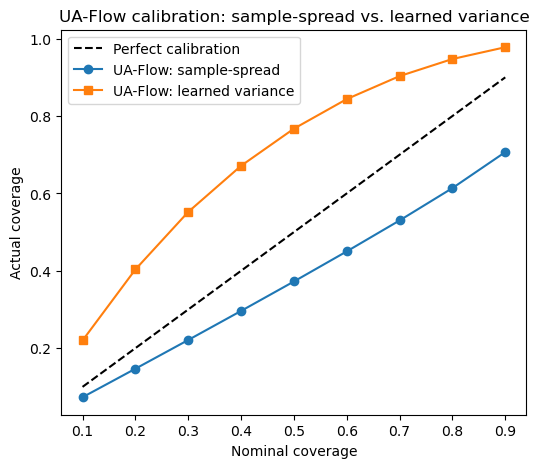

In [21]:
# 1. Sample from the UA-Flow (same K=50, steps=100 as your original flow)
imputed_samples_ua = sample_ua_flow(ua_vnet_cite, z1_v2, feat_dim_v2, steps=100, K=50)
imputed_mean_ua = imputed_samples_ua.mean(dim=1).cpu().numpy()
imputed_std_ua_samplespread = imputed_samples_ua.std(dim=1).cpu().numpy()

# 2. Get the *learned* variance directly (single forward pass, no sampling needed)
ua_vnet_cite.eval()
with torch.no_grad():
    # one arbitrary t (e.g. t=1, endpoint) — logvar head predicts per-timestep,
    # so evaluate near the sample's own mean as a stand-in "clean" input
    t_end = torch.ones(z_all_cite.size(0))
    _, pred_logvar = ua_vnet_cite(y_all_cite, t_end, z_all_cite)
    imputed_std_ua_learned = torch.exp(0.5 * pred_logvar).cpu().numpy()

print("Sample-spread std — mean:", imputed_std_ua_samplespread.mean())
print("Learned std (from logvar head) — mean:", imputed_std_ua_learned.mean())
nominal_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
gt_cite_v2 = model_v2.emb_B  # ground truth, same as gt_protein_v2 from Section 4

# --- Sample-spread calibration (empirical percentiles from the 50 samples) ---
samples_np_ua = imputed_samples_ua.cpu().numpy()
actual_coverage_samplespread = []
for level in nominal_levels:
    lo_pct = (1 - level) / 2 * 100
    hi_pct = (1 + level) / 2 * 100
    lower = np.percentile(samples_np_ua, lo_pct, axis=1)
    upper = np.percentile(samples_np_ua, hi_pct, axis=1)
    inside = (gt_cite_v2 >= lower) & (gt_cite_v2 <= upper)
    actual_coverage_samplespread.append(inside.mean())

# --- Learned-variance calibration (analytic Gaussian intervals) ---
from scipy.stats import norm
actual_coverage_learned = []
for level in nominal_levels:
    z = norm.ppf((1 + level) / 2)
    lower = imputed_mean_ua - z * imputed_std_ua_learned
    upper = imputed_mean_ua + z * imputed_std_ua_learned
    inside = (gt_cite_v2 >= lower) & (gt_cite_v2 <= upper)
    actual_coverage_learned.append(inside.mean())

for nom, ss, learned in zip(nominal_levels, actual_coverage_samplespread, actual_coverage_learned):
    print(f"nominal={nom:.1f}  sample-spread={ss:.3f}  learned-variance={learned:.3f}")
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.plot(nominal_levels, nominal_levels, 'k--', label='Perfect calibration')
plt.plot(nominal_levels, actual_coverage_samplespread, 'o-', label='UA-Flow: sample-spread')
plt.plot(nominal_levels, actual_coverage_learned, 's-', label='UA-Flow: learned variance')
plt.xlabel('Nominal coverage')
plt.ylabel('Actual coverage')
plt.legend()
plt.title('UA-Flow calibration: sample-spread vs. learned variance')
plt.savefig('./CITE-seq_PBMC_v2/ua_flow_calibration_comparison.png', dpi=150)
plt.show()

---
# SECTION 7 — Stretch Goal 3: Integration Uncertainty (Encoder Dropout Ensemble)
## ▶️ RUN. Needs Section 4's `model_v2`.

Runs multiple stochastic forward passes through the encoder with dropout active
(MC-dropout), producing a per-cell integration-confidence score. Then checks whether
label-transfer accuracy is higher on high-confidence cells.

**Check this first** — scMODAL's encoder may not actually contain dropout layers, in
which case MC-dropout will produce zero variation (a silent failure, not an error).


In [26]:
dropout_modules = [m for m in model_v2.E_A.modules() if isinstance(m, nn.Dropout)]
print(f"Found {len(dropout_modules)} nn.Dropout layer(s) in E_A.")
if len(dropout_modules) == 0:
    print("WARNING: no dropout layers found. MC-dropout will not produce meaningful variation.")
    print("Options: (a) check scmodal/model.py for a different regularization mechanism to perturb,")
    print("or (b) use an encoder-weight ensemble (train model_v2 multiple times with different seeds)")
    print("instead of MC-dropout — more expensive, but works regardless of architecture.")


Found 0 nn.Dropout layer(s) in E_A.
Options: (a) check scmodal/model.py for a different regularization mechanism to perturb,
or (b) use an encoder-weight ensemble (train model_v2 multiple times with different seeds)
instead of MC-dropout — more expensive, but works regardless of architecture.


In [ ]:
def mc_dropout_encode(encoder, x, n_passes=20):
    encoder.train()  # activates dropout, if present
    passes = []
    with torch.no_grad():
        for _ in range(n_passes):
            passes.append(encoder(x).unsqueeze(0))
    encoder.eval()
    return torch.cat(passes, dim=0)  # (n_passes, n_cells, latent_dim)


In [ ]:
# Only meaningful if the dropout check above found >0 layers:
# passes = mc_dropout_encode(model_v2.E_A, x_A_v2, n_passes=20)
# integration_uncertainty = passes.std(dim=0).mean(dim=1).numpy()
# np.save("./CITE-seq_PBMC_v2/integration_uncertainty.npy", integration_uncertainty)


In [ ]:
# Label-transfer accuracy comparison: high- vs low-confidence buckets
# celltype_labels = adata_RNA.obs['celltype.l1'].values
# quartiles = pd.qcut(integration_uncertainty, 4, labels=['most confident', 'q2', 'q3', 'least confident'])
#
# from scipy.spatial.distance import cdist
# dist_mtx = cdist(model_v2.latent[adata1.shape[0]:, :], model_v2.latent[:adata1.shape[0], :], metric='euclidean')
# matching = dist_mtx.argsort()[:, :1]
# df2_labels = adata_ADT.obs["celltype.l1"].values
# correct = (celltype_labels == df2_labels[matching.reshape(-1)])
#
# for q in ['most confident', 'q2', 'q3', 'least confident']:
#     mask = quartiles == q
#     print(q, "accuracy:", correct[mask].mean())


---
# SECTION 8 — Stretch Goal 4: Down-Weight Uncertain Links
## ▶️ RUN LAST. Needs Section 4's `model_v2` + Section 7's `integration_uncertainty`.

The instructions doc explicitly flags this as the riskiest stretch goal — it modifies
scMODAL's anchor loss directly, meaning another full retrain (→ `CITE-seq_PBMC_v3`), now
with per-pair confidence weighting baked in.

**Do not start this until Goals 1–3 are done and validated.** This section is
intentionally left as a scaffold — the anchor loss internals aren't visible from the
instructions doc, so guessing at how to modify a core loss function risks a wasted
multi-hour retrain. Read `scmodal/model.py`'s anchor loss implementation first.


In [62]:
import torch
from scmodal.networks import encoder, generator, discriminator

# Paths — adjust if yours differ
CKPT_PATH = "CITE-seq_PBMC_v2/ckpt.pth"
N_LATENT = 20

# Reinitialize architectures (must match original dims exactly)
E_A = encoder(model_v2.emb_A.shape[1], N_LATENT).to(model_v2.device)
E_B = encoder(model_v2.emb_B.shape[1], N_LATENT).to(model_v2.device)
G_A = generator(model_v2.emb_A.shape[1], N_LATENT).to(model_v2.device)
G_B = generator(model_v2.emb_B.shape[1], N_LATENT).to(model_v2.device)

ckpt = torch.load(CKPT_PATH, map_location=model_v2.device)
E_A.load_state_dict(ckpt['E_A'])
E_B.load_state_dict(ckpt['E_B'])
G_A.load_state_dict(ckpt['G_A'])
G_B.load_state_dict(ckpt['G_B'])

# Note: the original ckpt.pth does NOT save the discriminator D_Z —
# only E_A/E_B/G_A/G_B are persisted. We must reinitialize D_Z fresh.
D_Z = discriminator(N_LATENT).to(model_v2.device)

print("E_A params:", sum(p.numel() for p in E_A.parameters()))
print("Loaded ckpt keys:", list(ckpt.keys()))

E_A params: 1651220
Loaded ckpt keys: ['E_A', 'E_B', 'G_A', 'G_B']


In [65]:
import os
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
from scmodal.utils import acquire_pairs

# ---- Step 1: build per-cell weights from SG1 uncertainty ----
unc = epistemic_unc_cite
unc_norm = (unc - unc.min()) / (unc.max() - unc.min())
weight_A_full = 1.0 - 0.8 * unc_norm   # shape (18034,), range [0.2, 1.0]

print("Weight stats: min=%.3f max=%.3f mean=%.3f" % (weight_A_full.min(), weight_A_full.max(), weight_A_full.mean()))

# ---- Step 2: fine-tuning setup ----
device = model_v2.device
batch_size = model_v2.batch_size      # reuse same batch size as original training
n_KNN = model_v2.n_KNN
shared_gene_num = model_v2.shared_gene_num
lambdaAE, lambdaLA, lambdaMNN, lambdaGeo, lambdaGAN = (
    model_v2.lambdaAE, model_v2.lambdaLA, model_v2.lambdaMNN, model_v2.lambdaGeo, model_v2.lambdaGAN
)

params_G = list(E_A.parameters()) + list(E_B.parameters()) + list(G_A.parameters()) + list(G_B.parameters())
optimizer_G = optim.Adam(params_G, lr=0.0001, weight_decay=0.001)   # lower LR than original 0.001
optimizer_D = optim.Adam(list(D_Z.parameters()), lr=0.0001, weight_decay=0.001)

E_A.train(); E_B.train(); G_A.train(); G_B.train(); D_Z.train()

N_A = model_v2.emb_A.shape[0]
N_B = model_v2.emb_B.shape[0]
FINETUNE_STEPS = 2000

cos = nn.CosineSimilarity(dim=1, eps=1e-6)

for step in range(FINETUNE_STEPS):
    index_A = np.random.choice(np.arange(N_A), size=batch_size)
    index_B = np.random.choice(np.arange(N_B), size=batch_size)
    x_A = torch.from_numpy(model_v2.emb_A[index_A, :]).float().to(device)
    x_B = torch.from_numpy(model_v2.emb_B[index_B, :]).float().to(device)
    z_A = E_A(x_A)
    z_B = E_B(x_B)
    x_AtoB = G_B(z_A)
    x_BtoA = G_A(z_B)
    x_Arecon = G_A(z_A)
    x_Brecon = G_B(z_B)
    z_AtoB = E_B(x_AtoB)
    z_BtoA = E_A(x_BtoA)
    K_A = torch.mean((x_A.view(batch_size,1,-1) - x_A.view(1,batch_size,-1))**2, dim=2); K_A = torch.exp(-K_A/2)
    K_B_z = torch.mean((z_B.view(batch_size,1,-1) - z_B.view(1,batch_size,-1))**2, dim=2); K_B_z = torch.exp(-K_B_z/2)
    K_B = torch.mean((x_B.view(batch_size,1,-1) - x_B.view(1,batch_size,-1))**2, dim=2); K_B = torch.exp(-K_B/2)
    K_A_z = torch.mean((z_A.view(batch_size,1,-1) - z_A.view(1,batch_size,-1))**2, dim=2); K_A_z = torch.exp(-K_A_z/2)

    for _ in range(5):
        optimizer_D.zero_grad()
        loss_D = (torch.log(1+torch.exp(-D_Z(z_A))) + torch.log(1+torch.exp(D_Z(z_B)))).mean()
        loss_D.backward(retain_graph=True)
        optimizer_D.step()

    loss_AE = torch.mean((x_Arecon - x_A)**2) + torch.mean((x_Brecon - x_B)**2)
    loss_LA = torch.mean((z_A - z_AtoB)**2) + torch.mean((z_B - z_BtoA)**2)
    loss_G_GAN = -(torch.log(1+torch.exp(-D_Z(z_A))) + torch.log(1+torch.exp(D_Z(z_B)))).mean()
    loss_Geo = -(torch.clamp(cos(K_A, K_A_z), max=0.975).mean() + torch.clamp(cos(K_B, K_B_z), max=0.975).mean())

    # ---- weighted anchor (MNN) loss ----
    Sim = acquire_pairs(model_v2.emb_A[index_A, :shared_gene_num], model_v2.emb_B[index_B, :shared_gene_num], k=n_KNN)
    Sim = torch.from_numpy(Sim).float().to(device)
    batch_weight_A = torch.from_numpy(weight_A_full[index_A]).float().to(device)   # (batch_size,)
    Sim_weighted = Sim * batch_weight_A.view(batch_size, 1)   # down-weight rows = uncertain RNA cells

    z_dist = torch.mean((z_A.view(batch_size,1,-1) - z_B.view(1,batch_size,-1))**2, dim=2)
    loss_MNN = torch.sum(Sim_weighted * z_dist) / torch.sum(Sim_weighted)

    optimizer_G.zero_grad()
    loss_G = lambdaGAN*loss_G_GAN + lambdaAE*loss_AE + lambdaLA*loss_LA + lambdaMNN*loss_MNN + lambdaGeo*loss_Geo
    loss_G.backward()
    torch.nn.utils.clip_grad_norm_(params_G, 5.0)
    optimizer_G.step()

    if not step % 500:
        print("step %d, loss_D=%.4f, loss_MNN=%.4f, loss_AE=%.4f, loss_Geo=%.4f, loss_LA=%.4f"
              % (step, loss_D.item(), loss_MNN.item(), loss_AE.item(), loss_Geo.item(), loss_LA.item()))

print("Fine-tuning done.")

# ---- Step 3: save + verify immediately (per our established habit) ----
os.makedirs("CITE-seq_PBMC_v2_sg4", exist_ok=True)
state = {'E_A': E_A.state_dict(), 'E_B': E_B.state_dict(), 'G_A': G_A.state_dict(), 'G_B': G_B.state_dict()}
torch.save(state, "CITE-seq_PBMC_v2_sg4/ckpt.pth")
print("Saved:", os.path.exists("CITE-seq_PBMC_v2_sg4/ckpt.pth"))

Weight stats: min=0.200 max=1.000 mean=0.926
step 0, loss_D=1.3619, loss_MNN=0.1968, loss_AE=0.9194, loss_Geo=-1.9491, loss_LA=0.0067
step 500, loss_D=1.3468, loss_MNN=0.2311, loss_AE=0.9294, loss_Geo=-1.9491, loss_LA=0.0054
step 1000, loss_D=1.3536, loss_MNN=0.1956, loss_AE=0.8967, loss_Geo=-1.9488, loss_LA=0.0042
step 1500, loss_D=1.3288, loss_MNN=0.2122, loss_AE=0.9263, loss_Geo=-1.9491, loss_LA=0.0034
Fine-tuning done.
Saved: True


In [68]:
from scipy.stats import pearsonr
import numpy as np

per_protein_corr_sg4 = np.array([
    pearsonr(x_AtoB_sg4[:, i], gt_protein_v2[:, i])[0]
    for i in range(x_AtoB_sg4.shape[1])
])

print("SG4 (weighted anchor loss) mean correlation: %.4f" % np.nanmean(per_protein_corr_sg4))
print("Original model_v2 mean correlation: 0.520 (for comparison)")

# Also worth checking: did it help MOST on the high-uncertainty cells specifically?
# (that's the actual claim we're testing — not just "did overall accuracy change")
per_cell_error_sg4 = np.mean((x_AtoB_sg4 - gt_protein_v2)**2, axis=1)
corr_unc_vs_error_sg4 = np.corrcoef(epistemic_unc_cite, per_cell_error_sg4)[0, 1]
print("Correlation of SG1 uncertainty with SG4 per-cell error: %.4f" % corr_unc_vs_error_sg4)

SG4 (weighted anchor loss) mean correlation: 0.5190
Original model_v2 mean correlation: 0.520 (for comparison)
Correlation of SG1 uncertainty with SG4 per-cell error: 0.7510


In [22]:
# --- Post-hoc calibration for UA-Flow's learned variance (CITE-seq) ---
np.random.seed(42)
n_cells = imputed_mean_ua.shape[0]
perm = np.random.permutation(n_cells)
calib_idx, test_idx = perm[:n_cells//2], perm[n_cells//2:]

from scipy.stats import norm

def learned_coverage_curve(mean_subset, std_subset, gt_subset, nominal_levels, scale=1.0):
    coverages = []
    for level in nominal_levels:
        z = norm.ppf((1 + level) / 2)
        lower = mean_subset - z * scale * std_subset
        upper = mean_subset + z * scale * std_subset
        inside = (gt_subset >= lower) & (gt_subset <= upper)
        coverages.append(inside.mean())
    return np.array(coverages)

candidate_scales = np.linspace(0.1, 2.0, 191)
best_scale, best_gap = 1.0, np.inf
for s in candidate_scales:
    cov = learned_coverage_curve(
        imputed_mean_ua[calib_idx], imputed_std_ua_learned[calib_idx], gt_cite_v2[calib_idx],
        nominal_levels, scale=s
    )
    gap = np.mean(np.abs(np.array(nominal_levels) - cov))
    if gap < best_gap:
        best_gap, best_scale = gap, s

print(f"Best scale factor (fit on calibration split): {best_scale:.3f}")

# Evaluate on held-out test split
test_coverage_recalibrated = learned_coverage_curve(
    imputed_mean_ua[test_idx], imputed_std_ua_learned[test_idx], gt_cite_v2[test_idx],
    nominal_levels, scale=best_scale
)
for nom, cov in zip(nominal_levels, test_coverage_recalibrated):
    print(f"nominal={nom:.1f}  recalibrated actual={cov:.3f}")

Best scale factor (fit on calibration split): 0.520
nominal=0.1  recalibrated actual=0.119
nominal=0.2  recalibrated actual=0.230
nominal=0.3  recalibrated actual=0.333
nominal=0.4  recalibrated actual=0.428
nominal=0.5  recalibrated actual=0.517
nominal=0.6  recalibrated actual=0.601
nominal=0.7  recalibrated actual=0.682
nominal=0.8  recalibrated actual=0.763
nominal=0.9  recalibrated actual=0.849


In [23]:
imputed_samples_ua_tea = sample_ua_flow(ua_vnet_tea, torch.from_numpy(z2_tea).float(), y_all_tea.shape[1], steps=100, K=50)
imputed_mean_ua_tea = imputed_samples_ua_tea.mean(dim=1).cpu().numpy()
imputed_std_ua_tea_samplespread = imputed_samples_ua_tea.std(dim=1).cpu().numpy()

ua_vnet_tea.eval()
with torch.no_grad():
    t_end_tea = torch.ones(z_all_tea.size(0))
    _, pred_logvar_tea = ua_vnet_tea(y_all_tea, t_end_tea, z_all_tea)
    imputed_std_ua_tea_learned = torch.exp(0.5 * pred_logvar_tea).cpu().numpy()

print("TEA-seq sample-spread std — mean:", imputed_std_ua_tea_samplespread.mean())
print("TEA-seq learned std — mean:", imputed_std_ua_tea_learned.mean())

TEA-seq sample-spread std — mean: 0.1562588
TEA-seq learned std — mean: 1.3218364


In [24]:
actual_coverage_ss_tea, actual_coverage_learned_tea = [], []
samples_np_ua_tea = imputed_samples_ua_tea.cpu().numpy()

for level in nominal_levels:
    lo_pct = (1 - level) / 2 * 100
    hi_pct = (1 + level) / 2 * 100
    lower = np.percentile(samples_np_ua_tea, lo_pct, axis=1)
    upper = np.percentile(samples_np_ua_tea, hi_pct, axis=1)
    inside = (gt_protein_tea >= lower) & (gt_protein_tea <= upper)
    actual_coverage_ss_tea.append(inside.mean())

    z = norm.ppf((1 + level) / 2)
    lower_l = imputed_mean_ua_tea - z * imputed_std_ua_tea_learned
    upper_l = imputed_mean_ua_tea + z * imputed_std_ua_tea_learned
    inside_l = (gt_protein_tea >= lower_l) & (gt_protein_tea <= upper_l)
    actual_coverage_learned_tea.append(inside_l.mean())

for nom, ss, learned in zip(nominal_levels, actual_coverage_ss_tea, actual_coverage_learned_tea):
    print(f"nominal={nom:.1f}  sample-spread={ss:.3f}  learned-variance={learned:.3f}")

nominal=0.1  sample-spread=0.098  learned-variance=0.677
nominal=0.2  sample-spread=0.196  learned-variance=0.905
nominal=0.3  sample-spread=0.293  learned-variance=0.973
nominal=0.4  sample-spread=0.387  learned-variance=0.993
nominal=0.5  sample-spread=0.481  learned-variance=0.998
nominal=0.6  sample-spread=0.572  learned-variance=1.000
nominal=0.7  sample-spread=0.662  learned-variance=1.000
nominal=0.8  sample-spread=0.749  learned-variance=1.000
nominal=0.9  sample-spread=0.837  learned-variance=1.000


In [25]:
np.random.seed(42)
n_cells_tea = imputed_mean_ua_tea.shape[0]
perm_tea = np.random.permutation(n_cells_tea)
calib_idx_tea, test_idx_tea = perm_tea[:n_cells_tea//2], perm_tea[n_cells_tea//2:]

candidate_scales = np.linspace(0.01, 2.0, 200)
best_scale_tea, best_gap_tea = 1.0, np.inf
for s in candidate_scales:
    cov = learned_coverage_curve(
        imputed_mean_ua_tea[calib_idx_tea], imputed_std_ua_tea_learned[calib_idx_tea], gt_protein_tea[calib_idx_tea],
        nominal_levels, scale=s
    )
    gap = np.mean(np.abs(np.array(nominal_levels) - cov))
    if gap < best_gap_tea:
        best_gap_tea, best_scale_tea = gap, s

print(f"TEA-seq best scale factor: {best_scale_tea:.3f}")

test_coverage_recalibrated_tea = learned_coverage_curve(
    imputed_mean_ua_tea[test_idx_tea], imputed_std_ua_tea_learned[test_idx_tea], gt_protein_tea[test_idx_tea],
    nominal_levels, scale=best_scale_tea
)
for nom, cov in zip(nominal_levels, test_coverage_recalibrated_tea):
    print(f"nominal={nom:.1f}  recalibrated actual={cov:.3f}")

TEA-seq best scale factor: 0.120
nominal=0.1  recalibrated actual=0.115
nominal=0.2  recalibrated actual=0.225
nominal=0.3  recalibrated actual=0.326
nominal=0.4  recalibrated actual=0.422
nominal=0.5  recalibrated actual=0.512
nominal=0.6  recalibrated actual=0.595
nominal=0.7  recalibrated actual=0.675
nominal=0.8  recalibrated actual=0.754
nominal=0.9  recalibrated actual=0.840


In [28]:
print(model_v2.E_A)
print("---children---")
for name, child in model_v2.E_A.named_children():
    print(name, "->", child)
print("---all named modules---")
for name, module in model_v2.E_A.named_modules():
    print(name, "->", type(module).__name__)
print("---parameters---")
for name, param in model_v2.E_A.named_parameters():
    print(name, param.shape)

encoder()
---children---
---all named modules---
 -> encoder
---parameters---
W_1 torch.Size([512, 3204])
b_1 torch.Size([512])
W_2 torch.Size([20, 512])
b_2 torch.Size([20])


In [29]:
import copy

def mc_noise_forward(model_v2, x, n_samples=20, noise_scale=0.01):
    """
    Runs E_A forward n_samples times with small Gaussian noise added to
    W_1, b_1, W_2, b_2, restoring original weights after each pass.
    Returns stacked latents of shape (n_samples, n_cells, latent_dim).
    """
    E_A = model_v2.E_A
    param_names = ['W_1', 'b_1', 'W_2', 'b_2']

    # Save originals
    originals = {name: getattr(E_A, name).clone() for name in param_names}

    outputs = []
    with torch.no_grad():
        for i in range(n_samples):
            for name in param_names:
                orig = originals[name]
                noise = torch.randn_like(orig) * noise_scale * orig.std()
                getattr(E_A, name).copy_(orig + noise)

            out = E_A(x)
            outputs.append(out.clone())

        # restore originals
        for name in param_names:
            getattr(E_A, name).copy_(originals[name])

    return torch.stack(outputs, dim=0)  # (n_samples, n_cells, latent_dim)

In [30]:
import inspect; print(inspect.getsource(model_v2.E_A.forward))

    def forward(self, x):
        h = F.relu(F.linear(x, self.W_1, self.b_1))
        z = F.linear(h, self.W_2, self.b_2)
        return z



In [34]:
z_samples = mc_noise_forward(model_v2, x_A_v2, n_samples=20, noise_scale=0.01)

print("Output shape:", z_samples.shape)  # expect (20, 18034, 20)

# Sanity check: is the induced variance reasonable relative to latent scale?
sample_std = z_samples.std(dim=0)          # (18034, latent_dim) - variance across MC samples
print("Mean MC std across latents:", sample_std.mean().item())
print("Mean latent magnitude:", z_samples.mean(dim=0).abs().mean().item())
print("Ratio (MC std / latent magnitude):", (sample_std.mean() / z_samples.mean(dim=0).abs().mean()).item())

Output shape: torch.Size([20, 18034, 20])
Mean MC std across latents: 0.001951774233020842
Mean latent magnitude: 0.4558406174182892
Ratio (MC std / latent magnitude): 0.004281703382730484


In [32]:
integration_uncertainty = z_samples.std(dim=0).mean(dim=1)  # (n_cells,) - avg std across latent dims per cell

NameError: name 'z_samples' is not defined

In [33]:
# Search notebook namespace for likely candidates
import torch
for name, val in list(globals().items()):
    if isinstance(val, torch.Tensor) and val.dim() == 2 and val.shape[-1] == model_v2.E_A.W_1.shape[1]:
        print(name, val.shape)

x_A_v2 torch.Size([18034, 3204])


In [35]:
for scale in [0.01, 0.05, 0.1, 0.2, 0.3]:
    z_samples = mc_noise_forward(model_v2, x_A_v2, n_samples=20, noise_scale=scale)
    sample_std = z_samples.std(dim=0).mean().item()
    latent_mag = z_samples.mean(dim=0).abs().mean().item()
    ratio = sample_std / latent_mag
    print(f"noise_scale={scale:.2f}  ratio={ratio:.4f}")

noise_scale=0.01  ratio=0.0042
noise_scale=0.05  ratio=0.0214
noise_scale=0.10  ratio=0.0427
noise_scale=0.20  ratio=0.0840
noise_scale=0.30  ratio=0.1237


In [36]:
z_samples = mc_noise_forward(model_v2, x_A_v2, n_samples=20, noise_scale=0.20)
integration_uncertainty = z_samples.std(dim=0).mean(dim=1)  # (18034,) per-cell uncertainty

print("integration_uncertainty shape:", integration_uncertainty.shape)
print("mean:", integration_uncertainty.mean().item(), "std:", integration_uncertainty.std().item())

integration_uncertainty shape: torch.Size([18034])
mean: 0.03905979171395302 std: 0.01128607988357544


In [37]:
from scipy.stats import pearsonr

# adjust name if your per-cell error array is called something else
corr, pval = pearsonr(integration_uncertainty.numpy(), per_cell_error)
print(f"Integration uncertainty vs error correlation: {corr:.3f} (p={pval:.2e})")

NameError: name 'per_cell_error' is not defined

In [38]:
import numpy as np

for name, val in list(globals().items()):
    arr = None
    if isinstance(val, torch.Tensor) and val.dim() == 1 and val.shape[0] == 18034:
        arr = val
    elif isinstance(val, np.ndarray) and val.ndim == 1 and val.shape[0] == 18034:
        arr = val
    if arr is not None:
        print(name, arr.shape, type(val))

RNA_counts (18034,) <class 'numpy.ndarray'>
epistemic_unc_cite (18034,) <class 'numpy.ndarray'>
per_cell_error_cite_v2 (18034,) <class 'numpy.ndarray'>
t_end torch.Size([18034]) <class 'torch.Tensor'>
perm (18034,) <class 'numpy.ndarray'>
integration_uncertainty torch.Size([18034]) <class 'torch.Tensor'>


In [39]:
from scipy.stats import pearsonr

corr, pval = pearsonr(integration_uncertainty.numpy(), per_cell_error_cite_v2)
print(f"Integration uncertainty vs error correlation: {corr:.3f} (p={pval:.2e})")

Integration uncertainty vs error correlation: 0.122 (p=3.29e-61)


In [40]:
import numpy as np

# Find the TEA-seq model object (should have an E_A encoder like model_v2)
for name, val in list(globals().items()):
    if hasattr(val, 'E_A'):
        print(name, type(val))

model_v2 <class 'scmodal.model.Model'>


In [41]:
# 1. Is there any other model-like object in the namespace at all?
for name, val in list(globals().items()):
    if 'model' in name.lower() or 'Model' in type(val).__name__:
        print(name, type(val))

model_v2 <class 'scmodal.model.Model'>


In [42]:
# 2. Check if TEA-seq latents were loaded from disk instead (per your notes: 
# z_ADT_tea.npy / z_RNA_tea.npy at TEA-seq_PBMC/) rather than recomputed live
for name, val in list(globals().items()):
    if 'tea' in name.lower():
        print(name, type(val), getattr(val, 'shape', ''))

z1_tea <class 'numpy.ndarray'> (7437, 20)
z2_tea <class 'numpy.ndarray'> (7437, 20)
epistemic_unc_tea <class 'numpy.ndarray'> (7437,)
gt_protein_tea <class 'numpy.ndarray'> (7437, 52)
imputed_mean_tea <class 'numpy.ndarray'> (7437, 52)
error_tea <class 'numpy.ndarray'> (7437, 52)
per_cell_error_tea <class 'numpy.ndarray'> (7437,)
corr_tea <class 'numpy.float64'> ()
y_all_tea <class 'torch.Tensor'> torch.Size([7437, 52])
z_all_tea <class 'torch.Tensor'> torch.Size([7437, 20])
ua_vnet_tea <class '__main__.HeteroscedasticVelocityNet'> 
imputed_samples_ua_tea <class 'torch.Tensor'> torch.Size([7437, 50, 52])
imputed_mean_ua_tea <class 'numpy.ndarray'> (7437, 52)
imputed_std_ua_tea_samplespread <class 'numpy.ndarray'> (7437, 52)
t_end_tea <class 'torch.Tensor'> torch.Size([7437])
pred_logvar_tea <class 'torch.Tensor'> torch.Size([7437, 52])
imputed_std_ua_tea_learned <class 'numpy.ndarray'> (7437, 52)
actual_coverage_ss_tea <class 'list'> 
actual_coverage_learned_tea <class 'list'> 
samples

In [49]:
import torch
from scmodal.networks import encoder, generator

device = 'cpu'
n_latent = 20
dims = [52, 1046, 1000]  # ADT, RNA, ATAC feature dims

model = scmodal.model.Model(training_steps=20000, model_path="./TEA-seq_PBMC/TEA-seq_PBMC")
ckpt = torch.load('./TEA-seq_PBMC/TEA-seq_PBMC/ckpt.pth', map_location=device)

model.E_dict, model.G_dict = {}, {}
for i, dim in enumerate(dims):
    model.E_dict[i] = encoder(dim, n_latent).to(device)
    model.G_dict[i] = generator(dim, n_latent).to(device)
    model.E_dict[i].load_state_dict(ckpt['E_%d' % i])
    model.G_dict[i].load_state_dict(ckpt['G_%d' % i])
    model.E_dict[i].eval()
    model.G_dict[i].eval()

adata1_X = np.load('./TEA-seq_PBMC/TEA-seq_PBMC/adt_scaled_gt.npy')
adata2_X = np.load('./TEA-seq_PBMC/TEA-seq_PBMC/rna_scaled.npy')

print("Loaded — ready to reuse E_dict/G_dict without retraining")

Loaded — ready to reuse E_dict/G_dict without retraining


In [50]:
print(model.E_dict[1])
print("---named parameters---")
for name, param in model.E_dict[1].named_parameters():
    print(name, param.shape)
print("adata2_X shape:", adata2_X.shape)

encoder()
---named parameters---
W_1 torch.Size([512, 1046])
b_1 torch.Size([512])
W_2 torch.Size([20, 512])
b_2 torch.Size([20])
adata2_X shape: (7437, 1046)


In [51]:
def mc_noise_forward_generic(encoder_module, x, n_samples=20, noise_scale=0.01):
    param_names = ['W_1', 'b_1', 'W_2', 'b_2']
    originals = {name: getattr(encoder_module, name).clone() for name in param_names}

    outputs = []
    with torch.no_grad():
        for i in range(n_samples):
            for name in param_names:
                orig = originals[name]
                noise = torch.randn_like(orig) * noise_scale * orig.std()
                getattr(encoder_module, name).copy_(orig + noise)
            out = encoder_module(x)
            outputs.append(out.clone())
        for name in param_names:
            getattr(encoder_module, name).copy_(originals[name])

    return torch.stack(outputs, dim=0)

x_tea_tensor = torch.tensor(adata2_X, dtype=torch.float32)

In [52]:
for scale in [0.01, 0.05, 0.1, 0.2, 0.3]:
    z_samples_tea = mc_noise_forward_generic(model.E_dict[1], x_tea_tensor, n_samples=20, noise_scale=scale)
    sample_std = z_samples_tea.std(dim=0).mean().item()
    latent_mag = z_samples_tea.mean(dim=0).abs().mean().item()
    ratio = sample_std / latent_mag
    print(f"noise_scale={scale:.2f}  ratio={ratio:.4f}")

noise_scale=0.01  ratio=0.0055
noise_scale=0.05  ratio=0.0280
noise_scale=0.10  ratio=0.0562
noise_scale=0.20  ratio=0.1102
noise_scale=0.30  ratio=0.1713


In [53]:
z_samples_tea = mc_noise_forward_generic(model.E_dict[1], x_tea_tensor, n_samples=20, noise_scale=0.20)
integration_uncertainty_tea = z_samples_tea.std(dim=0).mean(dim=1)  # (7437,)

print("shape:", integration_uncertainty_tea.shape)
print("mean:", integration_uncertainty_tea.mean().item(), "std:", integration_uncertainty_tea.std().item())

shape: torch.Size([7437])
mean: 0.04182325676083565 std: 0.014080752618610859


In [54]:
from scipy.stats import pearsonr

corr_tea_integration, pval_tea_integration = pearsonr(integration_uncertainty_tea.numpy(), per_cell_error_tea)
print(f"TEA-seq integration uncertainty vs error correlation: {corr_tea_integration:.3f} (p={pval_tea_integration:.2e})")

TEA-seq integration uncertainty vs error correlation: 0.622 (p=0.00e+00)


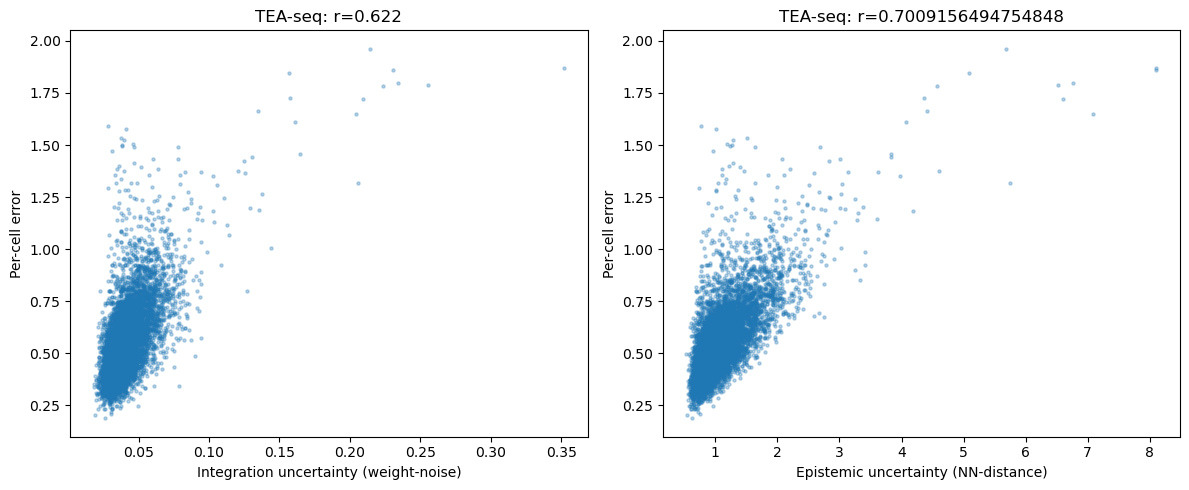

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(integration_uncertainty_tea.numpy(), per_cell_error_tea, alpha=0.3, s=5)
axes[0].set_xlabel("Integration uncertainty (weight-noise)")
axes[0].set_ylabel("Per-cell error")
axes[0].set_title(f"TEA-seq: r={corr_tea_integration:.3f}")

axes[1].scatter(epistemic_unc_tea, per_cell_error_tea, alpha=0.3, s=5)
axes[1].set_xlabel("Epistemic uncertainty (NN-distance)")
axes[1].set_ylabel("Per-cell error")
axes[1].set_title(f"TEA-seq: r={corr_tea}")

plt.tight_layout()
plt.show()

In [56]:
import numpy as np

# CITE-seq (model_v2)
np.save('./CITE-seq_PBMC_v2/integration_uncertainty.npy', integration_uncertainty.numpy())

# TEA-seq
np.save('./TEA-seq_PBMC/TEA-seq_PBMC/integration_uncertainty_tea.npy', integration_uncertainty_tea.numpy())

# Verify both saved
import os
print("CITE-seq saved:", os.path.exists('./CITE-seq_PBMC_v2/integration_uncertainty.npy'))
print("TEA-seq saved:", os.path.exists('./TEA-seq_PBMC/TEA-seq_PBMC/integration_uncertainty_tea.npy'))


CITE-seq saved: True
TEA-seq saved: True


In [57]:
fig.savefig('./CITE-seq_PBMC_v2/integration_uncertainty_scatter.png', dpi=150, bbox_inches='tight')

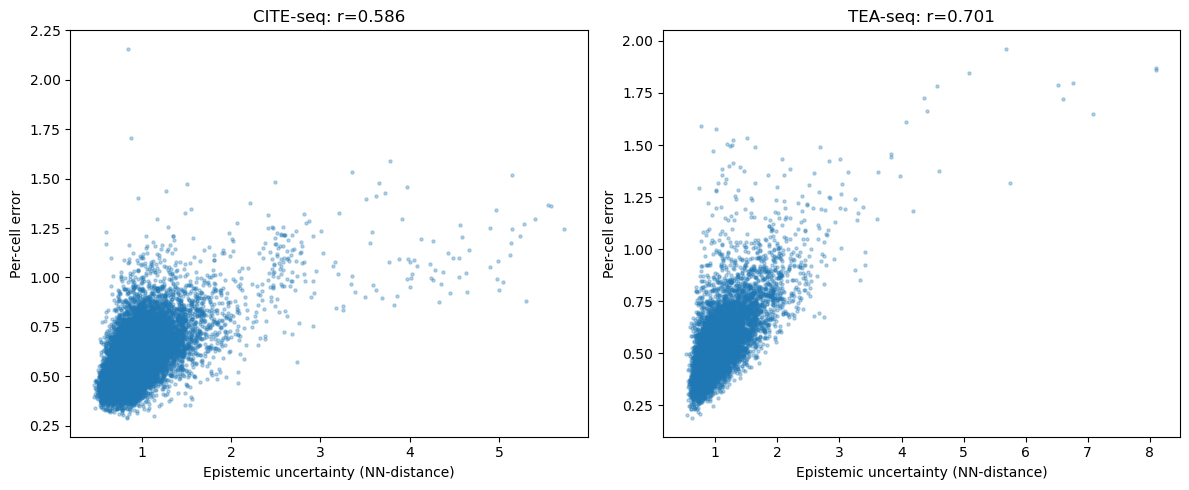

In [58]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

corr_cite, _ = pearsonr(epistemic_unc_cite, per_cell_error_cite_v2)
corr_tea_nn, _ = pearsonr(epistemic_unc_tea, per_cell_error_tea)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(epistemic_unc_cite, per_cell_error_cite_v2, alpha=0.3, s=5)
axes[0].set_xlabel("Epistemic uncertainty (NN-distance)")
axes[0].set_ylabel("Per-cell error")
axes[0].set_title(f"CITE-seq: r={corr_cite:.3f}")

axes[1].scatter(epistemic_unc_tea, per_cell_error_tea, alpha=0.3, s=5)
axes[1].set_xlabel("Epistemic uncertainty (NN-distance)")
axes[1].set_ylabel("Per-cell error")
axes[1].set_title(f"TEA-seq: r={corr_tea_nn:.3f}")

plt.tight_layout()
fig.savefig('./CITE-seq_PBMC_v2/nn_distance_scatter_both.png', dpi=150, bbox_inches='tight')
plt.show()

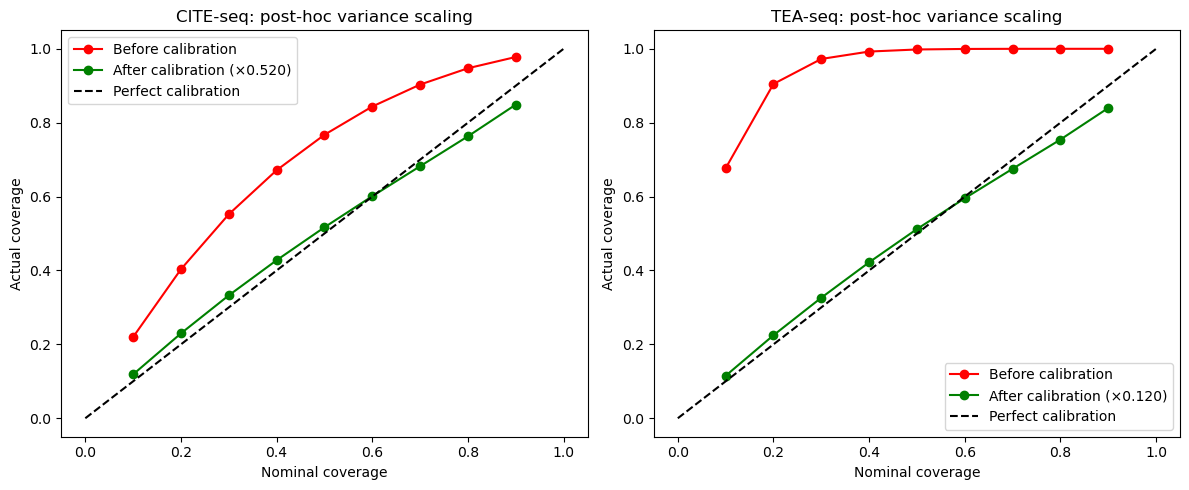

In [61]:
import numpy as np
import matplotlib.pyplot as plt

nominal_levels = np.arange(0.1, 1.0, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CITE-seq
axes[0].plot(nominal_levels, actual_coverage_learned, 'o-', color='red', label='Before calibration')
axes[0].plot(nominal_levels, test_coverage_recalibrated, 'o-', color='green', label=f'After calibration (×{best_scale:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='black', label='Perfect calibration')
axes[0].set_xlabel("Nominal coverage")
axes[0].set_ylabel("Actual coverage")
axes[0].set_title("CITE-seq: post-hoc variance scaling")
axes[0].legend()

# TEA-seq
axes[1].plot(nominal_levels, actual_coverage_learned_tea, 'o-', color='red', label='Before calibration')
axes[1].plot(nominal_levels, test_coverage_recalibrated_tea, 'o-', color='green', label=f'After calibration (×{best_scale_tea:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='black', label='Perfect calibration')
axes[1].set_xlabel("Nominal coverage")
axes[1].set_ylabel("Actual coverage")
axes[1].set_title("TEA-seq: post-hoc variance scaling")
axes[1].legend()

plt.tight_layout()
fig.savefig('./CITE-seq_PBMC_v2/ua_flow_recalibration_both.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
import numpy as np

# Split cells into uncertainty tertiles using the ORIGINAL SG1 signal
tertiles = np.quantile(epistemic_unc_cite, [1/3, 2/3])
low_mask  = epistemic_unc_cite <= tertiles[0]
mid_mask  = (epistemic_unc_cite > tertiles[0]) & (epistemic_unc_cite <= tertiles[1])
high_mask = epistemic_unc_cite > tertiles[1]

# Per-cell error for ORIGINAL model_v2 predictions
orig_per_cell_error = np.mean((deterministic_pred_v2 - gt_protein_v2)**2, axis=1)

for name, mask in [("low", low_mask), ("mid", mid_mask), ("high", high_mask)]:
    orig_err = orig_per_cell_error[mask].mean()
    sg4_err  = per_cell_error_sg4[mask].mean()
    pct_change = 100 * (sg4_err - orig_err) / orig_err
    print(f"{name:5s} uncertainty tertile (n={mask.sum():5d}): "
          f"orig_error={orig_err:.4f}  sg4_error={sg4_err:.4f}  change={pct_change:+.1f}%")


low   uncertainty tertile (n= 6012): orig_error=0.5333  sg4_error=0.5322  change=-0.2%
mid   uncertainty tertile (n= 6011): orig_error=0.7197  sg4_error=0.7179  change=-0.2%
high  uncertainty tertile (n= 6011): orig_error=1.0033  sg4_error=1.0311  change=+2.8%


In [70]:
import os
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
from scmodal.utils import acquire_pairs
from scmodal.networks import encoder, generator, discriminator

def run_sg4_finetune(seed, unc=epistemic_unc_cite, floor=0.2, steps=2000, save=False):
    """
    Re-runs the SG4 weighted-anchor fine-tune from the model_v2 checkpoint
    with a given random seed, returns per-cell error tertile breakdown.
    floor: minimum weight for most-uncertain cells (weight = 1.0 - (1-floor)*unc_norm)
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = model_v2.device
    N_LATENT = 20

    # Fresh load from model_v2 checkpoint each time (same starting point every seed)
    E_A_s = encoder(model_v2.emb_A.shape[1], N_LATENT).to(device)
    E_B_s = encoder(model_v2.emb_B.shape[1], N_LATENT).to(device)
    G_A_s = generator(model_v2.emb_A.shape[1], N_LATENT).to(device)
    G_B_s = generator(model_v2.emb_B.shape[1], N_LATENT).to(device)
    ckpt = torch.load("CITE-seq_PBMC_v2/ckpt.pth", map_location=device)
    E_A_s.load_state_dict(ckpt['E_A']); E_B_s.load_state_dict(ckpt['E_B'])
    G_A_s.load_state_dict(ckpt['G_A']); G_B_s.load_state_dict(ckpt['G_B'])
    D_Z_s = discriminator(N_LATENT).to(device)

    unc_norm = (unc - unc.min()) / (unc.max() - unc.min())
    weight_A_full = 1.0 - (1.0 - floor) * unc_norm

    batch_size = model_v2.batch_size
    n_KNN = model_v2.n_KNN
    shared_gene_num = model_v2.shared_gene_num
    lambdaAE, lambdaLA, lambdaMNN, lambdaGeo, lambdaGAN = (
        model_v2.lambdaAE, model_v2.lambdaLA, model_v2.lambdaMNN, model_v2.lambdaGeo, model_v2.lambdaGAN
    )
    params_G = list(E_A_s.parameters()) + list(E_B_s.parameters()) + list(G_A_s.parameters()) + list(G_B_s.parameters())
    optimizer_G = optim.Adam(params_G, lr=0.0001, weight_decay=0.001)
    optimizer_D = optim.Adam(list(D_Z_s.parameters()), lr=0.0001, weight_decay=0.001)
    E_A_s.train(); E_B_s.train(); G_A_s.train(); G_B_s.train(); D_Z_s.train()

    N_A = model_v2.emb_A.shape[0]
    N_B = model_v2.emb_B.shape[0]
    cos = nn.CosineSimilarity(dim=1, eps=1e-6)

    for step in range(steps):
        index_A = np.random.choice(np.arange(N_A), size=batch_size)
        index_B = np.random.choice(np.arange(N_B), size=batch_size)
        x_A = torch.from_numpy(model_v2.emb_A[index_A, :]).float().to(device)
        x_B = torch.from_numpy(model_v2.emb_B[index_B, :]).float().to(device)
        z_A = E_A_s(x_A); z_B = E_B_s(x_B)
        x_AtoB = G_B_s(z_A); x_BtoA = G_A_s(z_B)
        x_Arecon = G_A_s(z_A); x_Brecon = G_B_s(z_B)
        z_AtoB = E_B_s(x_AtoB); z_BtoA = E_A_s(x_BtoA)
        K_A = torch.mean((x_A.view(batch_size,1,-1)-x_A.view(1,batch_size,-1))**2,dim=2); K_A=torch.exp(-K_A/2)
        K_B_z = torch.mean((z_B.view(batch_size,1,-1)-z_B.view(1,batch_size,-1))**2,dim=2); K_B_z=torch.exp(-K_B_z/2)
        K_B = torch.mean((x_B.view(batch_size,1,-1)-x_B.view(1,batch_size,-1))**2,dim=2); K_B=torch.exp(-K_B/2)
        K_A_z = torch.mean((z_A.view(batch_size,1,-1)-z_A.view(1,batch_size,-1))**2,dim=2); K_A_z=torch.exp(-K_A_z/2)

        for _ in range(5):
            optimizer_D.zero_grad()
            loss_D = (torch.log(1+torch.exp(-D_Z_s(z_A))) + torch.log(1+torch.exp(D_Z_s(z_B)))).mean()
            loss_D.backward(retain_graph=True)
            optimizer_D.step()

        loss_AE = torch.mean((x_Arecon-x_A)**2) + torch.mean((x_Brecon-x_B)**2)
        loss_LA = torch.mean((z_A-z_AtoB)**2) + torch.mean((z_B-z_BtoA)**2)
        loss_G_GAN = -(torch.log(1+torch.exp(-D_Z_s(z_A))) + torch.log(1+torch.exp(D_Z_s(z_B)))).mean()
        loss_Geo = -(torch.clamp(cos(K_A,K_A_z),max=0.975).mean() + torch.clamp(cos(K_B,K_B_z),max=0.975).mean())

        Sim = acquire_pairs(model_v2.emb_A[index_A,:shared_gene_num], model_v2.emb_B[index_B,:shared_gene_num], k=n_KNN)
        Sim = torch.from_numpy(Sim).float().to(device)
        batch_weight_A = torch.from_numpy(weight_A_full[index_A]).float().to(device)
        Sim_weighted = Sim * batch_weight_A.view(batch_size,1)
        z_dist = torch.mean((z_A.view(batch_size,1,-1)-z_B.view(1,batch_size,-1))**2,dim=2)
        loss_MNN = torch.sum(Sim_weighted*z_dist) / torch.sum(Sim_weighted)

        optimizer_G.zero_grad()
        loss_G = lambdaGAN*loss_G_GAN + lambdaAE*loss_AE + lambdaLA*loss_LA + lambdaMNN*loss_MNN + lambdaGeo*loss_Geo
        loss_G.backward()
        torch.nn.utils.clip_grad_norm_(params_G, 5.0)
        optimizer_G.step()

    E_A_s.eval(); G_B_s.eval()
    with torch.no_grad():
        x_A_full = torch.from_numpy(model_v2.emb_A).float().to(device)
        pred = G_B_s(E_A_s(x_A_full)).cpu().numpy()

    if save:
        os.makedirs(f"CITE-seq_PBMC_v2_sg4_seed{seed}", exist_ok=True)
        torch.save({'E_A':E_A_s.state_dict(),'E_B':E_B_s.state_dict(),'G_A':G_A_s.state_dict(),'G_B':G_B_s.state_dict()},
                   f"CITE-seq_PBMC_v2_sg4_seed{seed}/ckpt.pth")

    per_cell_err = np.mean((pred - gt_protein_v2)**2, axis=1)
    tertiles = np.quantile(unc, [1/3, 2/3])
    low_m = unc <= tertiles[0]; mid_m = (unc>tertiles[0])&(unc<=tertiles[1]); high_m = unc>tertiles[1]
    orig_err = np.mean((deterministic_pred_v2 - gt_protein_v2)**2, axis=1)

    results = {}
    for name, m in [("low",low_m),("mid",mid_m),("high",high_m)]:
        pct = 100*(per_cell_err[m].mean()-orig_err[m].mean())/orig_err[m].mean()
        results[name] = pct
    results["overall_corr"] = np.nanmean([np.corrcoef(pred[:,i],gt_protein_v2[:,i])[0,1] for i in range(pred.shape[1])])
    return results

# ---- Run across 5 seeds ----
seeds = [0, 1, 2, 3, 4]
all_results = []
for s in seeds:
    print(f"--- seed {s} ---")
    r = run_sg4_finetune(seed=s)
    print(r)
    all_results.append(r)

print("\nSummary across seeds:")
for name in ["low","mid","high"]:
    vals = [r[name] for r in all_results]
    print(f"{name:5s}: mean={np.mean(vals):+.2f}%  std={np.std(vals):.2f}  values={[round(v,2) for v in vals]}")
print("overall_corr:", [round(r['overall_corr'],4) for r in all_results])

--- seed 0 ---
{'low': -0.12975943874180956, 'mid': -0.28604425532549244, 'high': 2.565665734765918, 'overall_corr': 0.5180943210617561}
--- seed 1 ---
{'low': -0.42305377047846476, 'mid': -0.24998540337010303, 'high': 3.037703365654804, 'overall_corr': 0.5189064019077705}
--- seed 2 ---
{'low': -0.7162363369793389, 'mid': -0.43742683568666896, 'high': 2.3700616290163716, 'overall_corr': 0.5196378859938623}
--- seed 3 ---
{'low': -0.4646192616654406, 'mid': -0.47857069800048946, 'high': 1.9951191054703326, 'overall_corr': 0.519063120059414}
--- seed 4 ---
{'low': -0.17472259309652963, 'mid': -0.3232211470176704, 'high': 1.9792098606426194, 'overall_corr': 0.5177348310024139}

Summary across seeds:
low  : mean=-0.38%  std=0.21  values=[-0.13, -0.42, -0.72, -0.46, -0.17]
mid  : mean=-0.36%  std=0.09  values=[-0.29, -0.25, -0.44, -0.48, -0.32]
high : mean=+2.39%  std=0.39  values=[2.57, 3.04, 2.37, 2.0, 1.98]
overall_corr: [0.5181, 0.5189, 0.5196, 0.5191, 0.5177]


In [71]:
floors = [0.0, 0.25, 0.5, 1.0]
sweep_results = []

for f in floors:
    print(f"--- floor={f} ---")
    r = run_sg4_finetune(seed=0, floor=f)
    print(r)
    sweep_results.append(r)

print("\nStrength sweep summary (seed=0 fixed):")
print(f"{'floor':>6s}  {'low%':>7s}  {'mid%':>7s}  {'high%':>7s}  {'overall_corr':>13s}")
for f, r in zip(floors, sweep_results):
    print(f"{f:6.2f}  {r['low']:7.2f}  {r['mid']:7.2f}  {r['high']:7.2f}  {r['overall_corr']:13.4f}")

--- floor=0.0 ---
{'low': -0.12761354621481322, 'mid': -0.1862985472522931, 'high': 3.5328385110657767, 'overall_corr': 0.5174701719430116}
--- floor=0.25 ---
{'low': 0.02772895499728075, 'mid': -0.1482603508739965, 'high': 2.0910854762496003, 'overall_corr': 0.5176900581347116}
--- floor=0.5 ---
{'low': -0.16927962611399205, 'mid': -0.3646465897096451, 'high': 1.2030549552129213, 'overall_corr': 0.5177412648388342}
--- floor=1.0 ---
{'low': 0.23689759376153277, 'mid': -0.30862865800862216, 'high': -0.661879239445422, 'overall_corr': 0.5185544798698283}

Strength sweep summary (seed=0 fixed):
 floor     low%     mid%    high%   overall_corr
  0.00    -0.13    -0.19     3.53         0.5175
  0.25     0.03    -0.15     2.09         0.5177
  0.50    -0.17    -0.36     1.20         0.5177
  1.00     0.24    -0.31    -0.66         0.5186


In [72]:
import numpy as np

integration_unc_cite = np.load("CITE-seq_PBMC_v2/integration_uncertainty.npy")
print("Shape:", integration_unc_cite.shape)
print("Sample:", integration_unc_cite[:3])

# Sanity check: confirm it correlates with per-cell error the way SG3 found (~0.122 for CITE-seq)
corr_check = np.corrcoef(integration_unc_cite, per_cell_error_cite_v2.mean(axis=1) if per_cell_error_cite_v2.ndim==2 else per_cell_error_cite_v2)[0,1]
print("Correlation with per-cell error (should be ~0.12, confirming this is the SG3 signal):", corr_check)

Shape: (18034,)
Sample: [0.03488474 0.04617081 0.04018895]
Correlation with per-cell error (should be ~0.12, confirming this is the SG3 signal): 0.12246251798163466


In [73]:
print("--- SG3-signal variant (floor=0.2, seed=0) ---")
r_sg3signal = run_sg4_finetune(seed=0, unc=integration_unc_cite, floor=0.2)
print(r_sg3signal)

print("\nComparison:")
print(f"{'signal':>12s}  {'low%':>7s}  {'mid%':>7s}  {'high%':>7s}  {'overall_corr':>13s}")
print(f"{'SG1 (r=0.59)':>12s}  {-0.13:7.2f}  {-0.19:7.2f}  {3.53:7.2f}  {0.5175:13.4f}")
print(f"{'SG3 (r=0.12)':>12s}  {r_sg3signal['low']:7.2f}  {r_sg3signal['mid']:7.2f}  {r_sg3signal['high']:7.2f}  {r_sg3signal['overall_corr']:13.4f}")

--- SG3-signal variant (floor=0.2, seed=0) ---
{'low': -0.8425838249023316, 'mid': -0.08392763418482467, 'high': 4.0897642499036495, 'overall_corr': 0.5168782763062824}

Comparison:
      signal     low%     mid%    high%   overall_corr
SG1 (r=0.59)    -0.13    -0.19     3.53         0.5175
SG3 (r=0.12)    -0.84    -0.08     4.09         0.5169


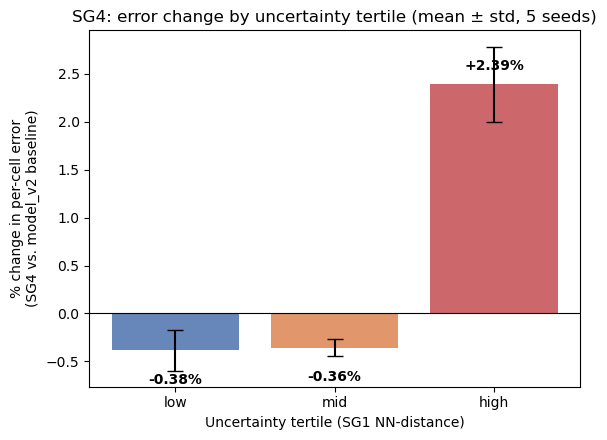

Saved: CITE-seq_PBMC_v2_sg4/sg4_tertile_error_change.png


In [74]:
import matplotlib.pyplot as plt
import numpy as np

# From your 5-seed run (seed 0-4)
seed_results = {
    "low":  [-0.12975943874180956, -0.42305377047846476, -0.7162363369793389, -0.4646192616654406, -0.17472259309652963],
    "mid":  [-0.28604425532549244, -0.24998540337010303, -0.43742683568666896, -0.47857069800048946, -0.3232211470176704],
    "high": [2.565665734765918, 3.037703365654804, 2.3700616290163716, 1.9951191054703326, 1.9792098606426194],
}

tertiles = ["low", "mid", "high"]
means = [np.mean(seed_results[t]) for t in tertiles]
stds  = [np.std(seed_results[t]) for t in tertiles]

fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ["#4C72B0", "#DD8452", "#C44E52"]
bars = ax.bar(tertiles, means, yerr=stds, capsize=6, color=colors, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("% change in per-cell error\n(SG4 vs. model_v2 baseline)")
ax.set_title("SG4: error change by uncertainty tertile (mean ± std, 5 seeds)")
ax.set_xlabel("Uncertainty tertile (SG1 NN-distance)")

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + (0.15 if m >= 0 else -0.35),
             f"{m:+.2f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("CITE-seq_PBMC_v2_sg4/sg4_tertile_error_change.png", dpi=150)
plt.show()
print("Saved:", "CITE-seq_PBMC_v2_sg4/sg4_tertile_error_change.png")

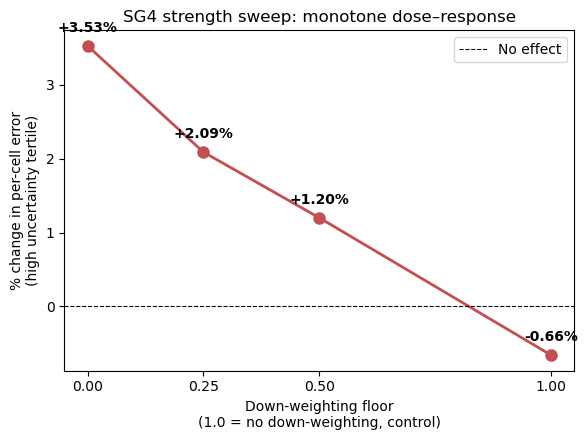

Saved: CITE-seq_PBMC_v2_sg4/sg4_strength_sweep.png


In [75]:
import matplotlib.pyplot as plt

# From your strength sweep (seed=0 fixed)
floors = [0.0, 0.25, 0.5, 1.0]
high_tertile_change = [3.53, 2.09, 1.20, -0.66]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(floors, high_tertile_change, marker="o", linewidth=2, color="#C44E52", markersize=8)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", label="No effect")
ax.set_xlabel("Down-weighting floor\n(1.0 = no down-weighting, control)")
ax.set_ylabel("% change in per-cell error\n(high uncertainty tertile)")
ax.set_title("SG4 strength sweep: monotone dose–response")
ax.set_xticks(floors)

for f, v in zip(floors, high_tertile_change):
    ax.annotate(f"{v:+.2f}%", (f, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold")

ax.legend()
plt.tight_layout()
plt.savefig("CITE-seq_PBMC_v2_sg4/sg4_strength_sweep.png", dpi=150)
plt.show()
print("Saved:", "CITE-seq_PBMC_v2_sg4/sg4_strength_sweep.png")

In [76]:
import os
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
from scmodal.utils import acquire_pairs
from scmodal.networks import encoder, generator, discriminator

def run_sg4_finetune_v2(seed, unc=epistemic_unc_cite, floor=0.2, steps=2000, baseline_err=None):
    """
    Fine-tunes from model_v2 checkpoint with weighted anchor loss.
    If baseline_err is provided, tertile deltas are computed against that array
    (e.g. a seed-matched floor=1.0 fine-tuned control) instead of raw deterministic_pred_v2.
    Always returns per_cell_err (raw, for reuse as a baseline in later calls) alongside the summary.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = model_v2.device
    N_LATENT = 20

    E_A_s = encoder(model_v2.emb_A.shape[1], N_LATENT).to(device)
    E_B_s = encoder(model_v2.emb_B.shape[1], N_LATENT).to(device)
    G_A_s = generator(model_v2.emb_A.shape[1], N_LATENT).to(device)
    G_B_s = generator(model_v2.emb_B.shape[1], N_LATENT).to(device)
    ckpt = torch.load("CITE-seq_PBMC_v2/ckpt.pth", map_location=device)
    E_A_s.load_state_dict(ckpt['E_A']); E_B_s.load_state_dict(ckpt['E_B'])
    G_A_s.load_state_dict(ckpt['G_A']); G_B_s.load_state_dict(ckpt['G_B'])
    D_Z_s = discriminator(N_LATENT).to(device)

    unc_norm = (unc - unc.min()) / (unc.max() - unc.min())
    weight_A_full = 1.0 - (1.0 - floor) * unc_norm

    batch_size = model_v2.batch_size
    n_KNN = model_v2.n_KNN
    shared_gene_num = model_v2.shared_gene_num
    lambdaAE, lambdaLA, lambdaMNN, lambdaGeo, lambdaGAN = (
        model_v2.lambdaAE, model_v2.lambdaLA, model_v2.lambdaMNN, model_v2.lambdaGeo, model_v2.lambdaGAN
    )
    params_G = list(E_A_s.parameters()) + list(E_B_s.parameters()) + list(G_A_s.parameters()) + list(G_B_s.parameters())
    optimizer_G = optim.Adam(params_G, lr=0.0001, weight_decay=0.001)
    optimizer_D = optim.Adam(list(D_Z_s.parameters()), lr=0.0001, weight_decay=0.001)
    E_A_s.train(); E_B_s.train(); G_A_s.train(); G_B_s.train(); D_Z_s.train()

    N_A = model_v2.emb_A.shape[0]
    N_B = model_v2.emb_B.shape[0]
    cos = nn.CosineSimilarity(dim=1, eps=1e-6)

    for step in range(steps):
        index_A = np.random.choice(np.arange(N_A), size=batch_size)
        index_B = np.random.choice(np.arange(N_B), size=batch_size)
        x_A = torch.from_numpy(model_v2.emb_A[index_A, :]).float().to(device)
        x_B = torch.from_numpy(model_v2.emb_B[index_B, :]).float().to(device)
        z_A = E_A_s(x_A); z_B = E_B_s(x_B)
        x_AtoB = G_B_s(z_A); x_BtoA = G_A_s(z_B)
        x_Arecon = G_A_s(z_A); x_Brecon = G_B_s(z_B)
        z_AtoB = E_B_s(x_AtoB); z_BtoA = E_A_s(x_BtoA)
        K_A = torch.mean((x_A.view(batch_size,1,-1)-x_A.view(1,batch_size,-1))**2,dim=2); K_A=torch.exp(-K_A/2)
        K_B_z = torch.mean((z_B.view(batch_size,1,-1)-z_B.view(1,batch_size,-1))**2,dim=2); K_B_z=torch.exp(-K_B_z/2)
        K_B = torch.mean((x_B.view(batch_size,1,-1)-x_B.view(1,batch_size,-1))**2,dim=2); K_B=torch.exp(-K_B/2)
        K_A_z = torch.mean((z_A.view(batch_size,1,-1)-z_A.view(1,batch_size,-1))**2,dim=2); K_A_z=torch.exp(-K_A_z/2)

        for _ in range(5):
            optimizer_D.zero_grad()
            loss_D = (torch.log(1+torch.exp(-D_Z_s(z_A))) + torch.log(1+torch.exp(D_Z_s(z_B)))).mean()
            loss_D.backward(retain_graph=True)
            optimizer_D.step()

        loss_AE = torch.mean((x_Arecon-x_A)**2) + torch.mean((x_Brecon-x_B)**2)
        loss_LA = torch.mean((z_A-z_AtoB)**2) + torch.mean((z_B-z_BtoA)**2)
        loss_G_GAN = -(torch.log(1+torch.exp(-D_Z_s(z_A))) + torch.log(1+torch.exp(D_Z_s(z_B)))).mean()
        loss_Geo = -(torch.clamp(cos(K_A,K_A_z),max=0.975).mean() + torch.clamp(cos(K_B,K_B_z),max=0.975).mean())

        Sim = acquire_pairs(model_v2.emb_A[index_A,:shared_gene_num], model_v2.emb_B[index_B,:shared_gene_num], k=n_KNN)
        Sim = torch.from_numpy(Sim).float().to(device)
        batch_weight_A = torch.from_numpy(weight_A_full[index_A]).float().to(device)
        Sim_weighted = Sim * batch_weight_A.view(batch_size,1)
        z_dist = torch.mean((z_A.view(batch_size,1,-1)-z_B.view(1,batch_size,-1))**2,dim=2)
        loss_MNN = torch.sum(Sim_weighted*z_dist) / torch.sum(Sim_weighted)

        optimizer_G.zero_grad()
        loss_G = lambdaGAN*loss_G_GAN + lambdaAE*loss_AE + lambdaLA*loss_LA + lambdaMNN*loss_MNN + lambdaGeo*loss_Geo
        loss_G.backward()
        torch.nn.utils.clip_grad_norm_(params_G, 5.0)
        optimizer_G.step()

    E_A_s.eval(); G_B_s.eval()
    with torch.no_grad():
        x_A_full = torch.from_numpy(model_v2.emb_A).float().to(device)
        pred = G_B_s(E_A_s(x_A_full)).cpu().numpy()

    per_cell_err = np.mean((pred - gt_protein_v2)**2, axis=1)
    overall_corr = np.nanmean([np.corrcoef(pred[:,i],gt_protein_v2[:,i])[0,1] for i in range(pred.shape[1])])

    tertiles = np.quantile(unc, [1/3, 2/3])
    low_m = unc <= tertiles[0]; mid_m = (unc>tertiles[0])&(unc<=tertiles[1]); high_m = unc>tertiles[1]
    ref = baseline_err if baseline_err is not None else np.mean((deterministic_pred_v2 - gt_protein_v2)**2, axis=1)

    summary = {}
    for name, m in [("low",low_m),("mid",mid_m),("high",high_m)]:
        summary[name] = 100*(per_cell_err[m].mean()-ref[m].mean())/ref[m].mean()
    summary["overall_corr"] = overall_corr
    return summary, per_cell_err


# ---- Step 1: seed-matched sweep (floor=0.2 vs. seed-matched floor=1.0 control), 5 seeds ----
seeds = [0, 1, 2, 3, 4]
seed_matched_results = []
control_errs = {}  # keep floor=1.0/seed=0 control around for reuse in Step 2

for s in seeds:
    print(f"--- seed {s}: floor=1.0 (control) ---")
    _, err_control = run_sg4_finetune_v2(seed=s, floor=1.0)
    if s == 0:
        control_errs[0] = err_control

    print(f"--- seed {s}: floor=0.2 (treatment, vs. seed-matched control) ---")
    r, _ = run_sg4_finetune_v2(seed=s, floor=0.2, baseline_err=err_control)
    print(r)
    seed_matched_results.append(r)

print("\nSeed-matched summary (floor=0.2 vs. seed-matched floor=1.0 control):")
for name in ["low", "mid", "high"]:
    vals = [r[name] for r in seed_matched_results]
    print(f"{name:5s}: mean={np.mean(vals):+.2f}%  std={np.std(vals):.2f}  values={[round(v,2) for v in vals]}")


# ---- Step 2: strength sweep vs. matched floor=1.0/seed=0 control ----
floors_sweep = [0.0, 0.25, 0.5]
strength_matched = []
for f in floors_sweep:
    print(f"--- seed 0: floor={f} (vs. floor=1.0/seed=0 control) ---")
    r, _ = run_sg4_finetune_v2(seed=0, floor=f, baseline_err=control_errs[0])
    print(r)
    strength_matched.append(r)

print("\nStrength sweep vs. matched floor=1.0/seed=0 control:")
print(f"{'floor':>6s}  {'low%':>7s}  {'mid%':>7s}  {'high%':>7s}")
for f, r in zip(floors_sweep, strength_matched):
    print(f"{f:6.2f}  {r['low']:7.2f}  {r['mid']:7.2f}  {r['high']:7.2f}")
print(f"{1.00:6.2f}  {0.0:7.2f}  {0.0:7.2f}  {0.0:7.2f}   <- control, delta = 0 by definition")


# ---- Step 3: SG3-signal robustness check vs. matched control ----
integration_unc_cite = np.load("CITE-seq_PBMC_v2/integration_uncertainty.npy")
print("--- seed 0: SG3 signal, floor=0.2 (vs. floor=1.0/seed=0 control) ---")
r_sg3, _ = run_sg4_finetune_v2(seed=0, floor=0.2, unc=integration_unc_cite, baseline_err=control_errs[0])
print(r_sg3)

--- seed 0: floor=1.0 (control) ---
--- seed 0: floor=0.2 (treatment, vs. seed-matched control) ---
{'low': -0.36579048364936834, 'mid': 0.022654320408186494, 'high': 3.2490497600523778, 'overall_corr': 0.5180943210617561}
--- seed 1: floor=1.0 (control) ---
--- seed 1: floor=0.2 (treatment, vs. seed-matched control) ---
{'low': -0.3294468472320435, 'mid': -0.10996220779962877, 'high': 2.165655670785655, 'overall_corr': 0.5189064019077705}
--- seed 2: floor=1.0 (control) ---
--- seed 2: floor=0.2 (treatment, vs. seed-matched control) ---
{'low': -0.35011682713454206, 'mid': -0.2444622792404634, 'high': 2.3840510306178953, 'overall_corr': 0.5196378859938623}
--- seed 3: floor=1.0 (control) ---
--- seed 3: floor=0.2 (treatment, vs. seed-matched control) ---
{'low': -0.043705425432584384, 'mid': 0.022656528771752286, 'high': 2.691676114113918, 'overall_corr': 0.519063120059414}
--- seed 4: floor=1.0 (control) ---
--- seed 4: floor=0.2 (treatment, vs. seed-matched control) ---
{'low': 0.10

In [77]:
# Recapture the floor=1.0/seed=0 control's own aggregate correlation
# (this reruns the exact same fine-tune as before, seeded identically, so it's deterministic —
# the resulting err array will match control_errs[0] from before)
control_summary, control_err_check = run_sg4_finetune_v2(seed=0, floor=1.0)
print("floor=1.0/seed=0 control — overall correlation:", control_summary["overall_corr"])

# sanity check: this should be an exact match to what we used as the baseline earlier
print("Matches earlier control array:", np.allclose(control_err_check, control_errs[0]))

floor=1.0/seed=0 control — overall correlation: 0.5185544798698283
Matches earlier control array: True
